In [1]:
import os
import json
import pickle

os.environ["RAY_DISABLE_WINDOWS_JOB_OBJECT"] = "1"

from datetime import datetime

import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from torch.utils.data import DataLoader
from torch.utils.data import Dataset

from sklearn.model_selection import TimeSeriesSplit

from optuna.samplers import TPESampler
from optuna.pruners import SuccessiveHalvingPruner
import matplotlib.pyplot as plt
from scipy import stats

from model import TCNRegressor
from tuning import ray_train
from ray import tune
from ray.tune import RunConfig
from ray.tune import Tuner
from ray.tune.schedulers import ASHAScheduler
from ray.tune.search.optuna import OptunaSearch
from ray.tune import CLIReporter


import train
import utils
from utils import plot_residual_diagnostics
import tuning
import data
from data import transform_data
from data import TimeSeriesDataset
from data import transform_with_scaler

if torch.xpu.is_available():
    device = torch.device("xpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

import sarima as sm

C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-09 15:01:29,225	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-09 15:01:29,582	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
import torch

print(f"PyTorch version: {torch.__version__}")

has_xpu_attr = hasattr(torch, "xpu")
xpu_compiled = hasattr(torch._C, "_xpu_getDeviceCount")
xpu_available = has_xpu_attr and torch.xpu.is_available()

print(f"XPU compiled: {xpu_compiled}")
print(f"XPU available: {xpu_available}")

if xpu_available:
    print(f"Device count: {torch.xpu.device_count()}")
    print(f"Device name: {torch.xpu.get_device_name(0)}")
    test_device = "xpu"
else:
    print("Device count: 0")
    print("Device name: N/A")
    test_device = "cuda" if torch.cuda.is_available() else "cpu"

# Test tensor creation
x = torch.randn(3, 3, device=test_device)
print(f"Test tensor: {x.size()} {x.device}")

PyTorch version: 2.7.1+xpu
XPU compiled: True
XPU available: True
Device count: 1
Device name: Intel(R) Arc(TM) Graphics
Test tensor: torch.Size([3, 3]) xpu:0


In [3]:
# Ray Windows fallback: ignore only AssignProcessToJobObject WinError 203
if os.name == "nt":
    import ray._private.utils as ray_private_utils

    _orig_attr = "_copilot_original_set_kill_child_on_death_win32"
    current_fn = ray_private_utils.set_kill_child_on_death_win32

    # Keep the true original function once so this patch is safe to re-run.
    original_fn = getattr(ray_private_utils, _orig_attr, None)
    if original_fn is None:
        original_fn = getattr(current_fn, "__wrapped__", current_fn)
        setattr(ray_private_utils, _orig_attr, original_fn)

    def _safe_set_kill_child_on_death_win32(child_proc):
        try:
            return original_fn(child_proc)
        except OSError as exc:
            if getattr(exc, "errno", None) == 203 or "AssignProcessToJobObject" in str(exc):
                return
            raise

    _safe_set_kill_child_on_death_win32.__wrapped__ = original_fn
    _safe_set_kill_child_on_death_win32._copilot_safe_wrapper = True

    # Idempotent assignment: avoid wrapping repeatedly on notebook re-execution.
    if not getattr(current_fn, "_copilot_safe_wrapper", False):
        ray_private_utils.set_kill_child_on_death_win32 = _safe_set_kill_child_on_death_win32
    else:
        # Ensure wrapper points at the stored original function.
        ray_private_utils.set_kill_child_on_death_win32.__wrapped__ = original_fn


In [4]:
LABEL_COLS  = ['Tax Revenues', 'BIR','BOC','Other Offices', 'Expenditures']
START_DATES = ["2000-01-01"]
FEATURE_CONFIGS = {
    'Tax Revenues': {
        "tag":          "feat_select",
        "features":     ['BIR', 'Imports_PHPMN', 'Other Offices', 'Non-tax Revenues', 'USDPHP', 'Inflation'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [],
        "use_lags":     False,
    },
    'BIR': {
        "tag":          "feat_select",
        "features":     ['Tax Revenues', 'Imports_PHPMN', 'Other Offices', 'USDPHP', 'Non-tax Revenues', 'Inflation'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [],
        "use_lags":     False,
    },
    'BOC': {
        "tag":          "feat_select",
        "features":     ['Imports_PHPMN', 'Other Offices', 'USDPHP', 'Non-tax Revenues'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [1],
        "use_lags":     True,
    },
    'Other Offices': {
        "tag":          "feat_select",
        "features":     ['Pop_disagg','Imports_PHPMN', 'Non-tax Revenues', 'USDPHP'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [1,3,6, 12],
        "use_lags":     True,
    },
    'Expenditures': {
        "tag":          "feat_select",
        "features":     ['Imports_PHPMN','Non-tax Revenues', 'USDPHP', 'Inflation'],
        "dummy_vars":   ['TRAIN', 'CREATE', 'COVID-19'],
        "use_seasonal": True,
        "lag_periods":  [12],
        "use_lags":     True,
    },
}

In [5]:
trials = 50
reporter = CLIReporter(
    metric="combined", mode="min",
    metric_columns=["loss", "peak_loss", "combined", "dir_acc", "std"],
    max_progress_rows=15,
    print_intermediate_tables=True,
    max_report_frequency=30,
    sort_by_metric=True,
)

BASE_SEARCH_SPACE = {
    "num_channels":  tune.choice([[64], [64, 64], [64, 64, 64], [128], [128, 128], [256], [256, 256]]),
    "kernel_size":   tune.choice([2, 3, 4]),
    "dropout":       tune.uniform(0.1, 0.4),
    "lr":            tune.loguniform(5e-4, 5e-2),
    "wd":            tune.loguniform(1e-6, 1e-4),
    "factor":        tune.uniform(0.2, 0.5),
    "patience":      tune.choice([5, 10]),
    "batch_size":    tune.choice([16, 32, 64]),
    "seq_len":       tune.choice([12, 18, 24]),
    "l1_lambda":     tune.loguniform(1e-5, 1e-2),
    "lag_periods":   [1, 3, 6, 12]
}

SEED_CONFIG = {
    "num_channels": [128, 128],
    "kernel_size": 3,
    "dropout": 0.1,
    "lr": 1e-3,
    "wd": 1e-5,
    "factor": 0.3,
    "patience": 5,
    "batch_size": 32,
    "seq_len": 12,
    "l1_lambda": 1e-5,
}

resources = {"cpu": 4, **({"gpu": 0.25} if torch.cuda.is_available() else {})}

all_results = {}

for start_date in START_DATES:
    all_results[start_date] = {}

    for label in LABEL_COLS:
        label_slug = label.replace(' ', '_')
        tag = FEATURE_CONFIGS[label].get("tag", "")
        exp_name = f"{label_slug}_{start_date[:4]}_{tag}" if tag else f"{label_slug}_{start_date[:4]}"

        print(f"\n{'='*60}\n  TUNING: {label} | Start: {start_date[:4]}\n{'='*60}")

        search_space = {
            **BASE_SEARCH_SPACE,
            **FEATURE_CONFIGS[label],
            "labels": [label],
            "experiment_name": exp_name,
            "start_date": start_date,
        }

        search_alg = OptunaSearch(
            metric="combined", mode="min",
            points_to_evaluate=[SEED_CONFIG],
        )

        tuner = Tuner(
            tune.with_resources(ray_train, resources=resources),
            tune_config=tune.TuneConfig(
                search_alg=search_alg,
                num_samples=trials,
                trial_dirname_creator=lambda trial: f"trial_{trial.trial_id}",
                max_concurrent_trials=4,
            ),
            run_config=RunConfig(
                name=f"tcn_{exp_name}",
                storage_path=os.path.abspath("ray_results"),
                verbose=1,
                progress_reporter=reporter,
            ),
            param_space=search_space,
        )

        results = tuner.fit()
        best_result = results.get_best_result(metric="combined", mode="min")
        best_config = best_result.config
        best_metrics = best_result.metrics

        exp_folder = f"configs/{exp_name}"
        os.makedirs(exp_folder, exist_ok=True)
        with open(f"{exp_folder}/best_config.json", "w") as f:
            json.dump(best_config, f, indent=4)

        all_results[start_date][label] = best_metrics
        print(f"  Best: MAPE={best_metrics['loss']:.2f}% | Peak={best_metrics['peak_loss']:.2f}% | DirAcc={best_metrics['dir_acc']:.3f}")

print(f"\n{'='*60}\n  TUNING SUMMARY\n{'='*60}")
print(pd.DataFrame([
    {"Start": sd[:4], "Label": lb, "MAPE": f"{m['loss']:.2f}",
     "Peak": f"{m['peak_loss']:.2f}", "DirAcc": f"{m['dir_acc']:.3f}",
     "Combined": f"{m['combined']:.2f}"}
    for sd, labels in all_results.items()
    for lb, m in labels.items()
]).to_string(index=False))


  TUNING: Tax Revenues | Start: 2000


2026-04-09 15:02:20,340	INFO worker.py:1832 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2026-04-09 15:02:24,425	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.
2026-04-09 15:02:24,448	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
[I 2026-04-09 15:02:24,454] A new study created in memory with name: optuna


== Status ==
Current time: 2026-04-09 15:02:25 (running for 00:00:00.26)
Using FIFO scheduling algorithm.
Logical resource usage: 0/22 CPUs, 0/0 GPUs
Result logdir: C:/Users/Jojie/AppData/Local/Temp/ray/session_2026-04-09_15-02-04_021962_41988/artifacts/2026-04-09_15-02-24/tcn_Tax_Revenues_2000_feat_select/driver_artifacts
Number of trials: 1/50 (1 PENDING)
+--------------------+----------+-------+--------------+-----------+----------+---------------+-------------+-------+----------------+------------+-----------+-------+
| Trial name         | status   | loc   |   batch_size |   dropout |   factor |   kernel_size |   l1_lambda |    lr | num_channels   |   patience |   seq_len |    wd |
|--------------------+----------+-------+--------------+-----------+----------+---------------+-------------+-------+----------------+------------+-----------+-------|
| ray_train_59f6e8e8 | PENDING  |       |           32 |       0.1 |      0.3 |             3 |       1e-05 | 0.001 | [128, 128]     |  

(ray_train pid=44564) C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
(ray_train pid=44564)   WeightNorm.apply(module, name, dim)


== Status ==
Current time: 2026-04-09 15:02:55 (running for 00:00:30.34)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/22 CPUs, 0/0 GPUs
Result logdir: C:/Users/Jojie/AppData/Local/Temp/ray/session_2026-04-09_15-02-04_021962_41988/artifacts/2026-04-09_15-02-24/tcn_Tax_Revenues_2000_feat_select/driver_artifacts
Number of trials: 2/50 (1 PENDING, 1 RUNNING)
+--------------------+----------+-----------------+--------------+-----------+----------+---------------+-------------+-----------+----------------+------------+-----------+-------------+
| Trial name         | status   | loc             |   batch_size |   dropout |   factor |   kernel_size |   l1_lambda |        lr | num_channels   |   patience |   seq_len |          wd |
|--------------------+----------+-----------------+--------------+-----------+----------+---------------+-------------+-----------+----------------+------------+-----------+-------------|
| ray_train_59f6e8e8 | RUNNING  | 127.0.0.1:44564 |           3

...

== Status ==
Current time: 2026-04-09 17:20:40 (running for 00:39:05.91)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/22 CPUs, 0/0 GPUs
Current best trial: f71d052a with combined=23.820869560549333 and parameters={'num_channels': [256, 256], 'kernel_size': 4, 'dropout': 0.2393645423386572, 'lr': 0.004254159799838298, 'wd': 3.581868425036525e-05, 'factor': 0.28072710801078415, 'patience': 5, 'batch_size': 32, 'seq_len': 18, 'l1_lambda': 0.00010566822327931556, 'lag_periods': [12], 'tag': 'feat_select', 'features': ['Imports_PHPMN', 'Non-tax Revenues', 'USDPHP', 'Inflation'], 'dummy_vars': ['TRAIN', 'CREATE', 'COVID-19'], 'use_seasonal': True, 'use_lags': True, 'labels': ['Expenditures'], 'experiment_name': 'Expenditures_2000_feat_select', 'start_date': '2000-01-01'}
Result logdir: C:/Users/Jojie/AppData/Local/Temp/ray/session_2026-04-09_15-02-04_021962_41988/artifacts/2026-04-09_16-41-34/tcn_Expenditures_2000_feat_select/driver_artifacts
Number of trials: 50/50 (2 RUNNIN

(ray_train pid=23660) C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
(ray_train pid=23660)   WeightNorm.apply(module, name, dim)
(ray_train pid=42232) C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
(ray_train pid=42232)   WeightNorm.apply(module, name, dim)


== Status ==
Current time: 2026-04-09 17:21:10 (running for 00:39:35.93)
Using FIFO scheduling algorithm.
Logical resource usage: 8.0/22 CPUs, 0/0 GPUs
Current best trial: f71d052a with combined=23.820869560549333 and parameters={'num_channels': [256, 256], 'kernel_size': 4, 'dropout': 0.2393645423386572, 'lr': 0.004254159799838298, 'wd': 3.581868425036525e-05, 'factor': 0.28072710801078415, 'patience': 5, 'batch_size': 32, 'seq_len': 18, 'l1_lambda': 0.00010566822327931556, 'lag_periods': [12], 'tag': 'feat_select', 'features': ['Imports_PHPMN', 'Non-tax Revenues', 'USDPHP', 'Inflation'], 'dummy_vars': ['TRAIN', 'CREATE', 'COVID-19'], 'use_seasonal': True, 'use_lags': True, 'labels': ['Expenditures'], 'experiment_name': 'Expenditures_2000_feat_select', 'start_date': '2000-01-01'}
Result logdir: C:/Users/Jojie/AppData/Local/Temp/ray/session_2026-04-09_15-02-04_021962_41988/artifacts/2026-04-09_16-41-34/tcn_Expenditures_2000_feat_select/driver_artifacts
Number of trials: 50/50 (2 RUNNIN

2026-04-09 17:21:28,208	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'c:/Users/Jojie/Desktop/School/Masters/Sem 2/01 Capstone/TCN/ray_results/tcn_Expenditures_2000_feat_select' in 0.1352s.
2026-04-09 17:21:28,258	INFO tune.py:1041 -- Total run time: 2393.35 seconds (2393.15 seconds for the tuning loop).


== Status ==
Current time: 2026-04-09 17:21:28 (running for 00:39:53.28)
Using FIFO scheduling algorithm.
Logical resource usage: 4.0/22 CPUs, 0/0 GPUs
Current best trial: f71d052a with combined=23.820869560549333 and parameters={'num_channels': [256, 256], 'kernel_size': 4, 'dropout': 0.2393645423386572, 'lr': 0.004254159799838298, 'wd': 3.581868425036525e-05, 'factor': 0.28072710801078415, 'patience': 5, 'batch_size': 32, 'seq_len': 18, 'l1_lambda': 0.00010566822327931556, 'lag_periods': [12], 'tag': 'feat_select', 'features': ['Imports_PHPMN', 'Non-tax Revenues', 'USDPHP', 'Inflation'], 'dummy_vars': ['TRAIN', 'CREATE', 'COVID-19'], 'use_seasonal': True, 'use_lags': True, 'labels': ['Expenditures'], 'experiment_name': 'Expenditures_2000_feat_select', 'start_date': '2000-01-01'}
Result logdir: C:/Users/Jojie/AppData/Local/Temp/ray/session_2026-04-09_15-02-04_021962_41988/artifacts/2026-04-09_16-41-34/tcn_Expenditures_2000_feat_select/driver_artifacts
Number of trials: 50/50 (50 TERMI

In [25]:
# FINAL MODEL TRAINING
# ============================================================

import importlib
import data
import train
importlib.reload(data)
importlib.reload(train)
from data import transform_data, transform_with_scaler, TimeSeriesDataset

final_results = {}

for start_date in START_DATES:
    final_results[start_date] = {}

    for label in LABEL_COLS:
        label_slug = label.replace(' ', '_')
        feature_config = dict(FEATURE_CONFIGS[label])
        tag = feature_config.get("tag", "")
        exp_name = f"{label_slug}_{start_date[:4]}_{tag}" if tag else f"{label_slug}_{start_date[:4]}"
        results_folder = f"results/{exp_name}"
        os.makedirs(results_folder, exist_ok=True)

        print(f"\n{'='*60}\n  FINAL TRAINING: {label} | Start: {start_date[:4]}\n{'='*60}")

        with open(f"configs/{exp_name}/best_config.json") as f:
            best_config = json.load(f)

        arch_keys   = ['hidden_size', 'num_layers', 'dropout', 'use_attention', 'use_branches',
                       'use_se', 'lr', 'wd', 'factor', 'patience', 'batch_size', 'seq_len',
                       'l1_lambda', 'train_loss_name', 'early_stopping_patience',
                       'num_channels', 'kernel_size']
        arch_config = {k: best_config[k] for k in arch_keys if k in best_config}

        quantile_loss = train.QuantileLoss() if hasattr(train, "QuantileLoss") else nn.MSELoss()
        directional_loss = train.DirectionalLoss(alpha=0.5) if hasattr(train, "DirectionalLoss") else nn.MSELoss()
        mad_loss = train.MADLoss() if hasattr(train, "MADLoss") else nn.L1Loss()

        args = train.Arguments(
            **arch_config,
            **feature_config,
            labels=[label],
            seed=1,
            epoch=200,
            experiment_name=exp_name,
            start_date=start_date,
            device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
            train_criterion={
                "huber": nn.HuberLoss(),
                "rmse": train.RMSELoss(),
                "mse": nn.MSELoss(),
                "quantile": quantile_loss,
                "mae": nn.L1Loss(),
                "directional": directional_loss,
                "madl": mad_loss,
            }.get(arch_config.get('train_loss_name', 'mse'), nn.MSELoss()),
            test_criterion=train.MAPELoss(),
            log_transform=best_config.get('log_transform', False),
            skip_log_cols=best_config.get('skip_log_cols', [])
        )

        # ── Data ──────────────────────────────────────────────────
        dataset = train.load_dataset(args)
        train_size = int(0.75 * len(dataset['cv_data']))

        final_train_data, final_train_labels = dataset['cv_data'][:train_size], dataset['cv_labels'][:train_size]
        final_val_data, final_val_labels = dataset['cv_data'][train_size:], dataset['cv_labels'][train_size:]

        train_scaled_res = transform_data(final_train_data, f"Transforms/{exp_name}/train_scaled.pkl")
        label_scaled_res = transform_data(final_train_labels, f"Transforms/{exp_name}/labels_scaled.pkl")

        if isinstance(train_scaled_res, tuple):
            final_train_scaled, data_scaler = train_scaled_res
            final_val_scaled = data_scaler.transform(final_val_data)
            final_test_scaled = data_scaler.transform(dataset['test_data'])
        else:
            final_train_scaled = train_scaled_res
            data_scaler = None
            final_val_scaled = transform_with_scaler(final_val_data, f"Transforms/{exp_name}/train_scaled.pkl")
            final_test_scaled = transform_with_scaler(dataset['test_data'], f"Transforms/{exp_name}/train_scaled.pkl")

        if isinstance(label_scaled_res, tuple):
            final_train_labels_scaled, label_scaler = label_scaled_res
            final_val_labels_scaled = label_scaler.transform(final_val_labels)
            final_test_labels_scaled = label_scaler.transform(dataset['test_labels'])
        else:
            final_train_labels_scaled = label_scaled_res
            label_scaler = None
            final_val_labels_scaled = transform_with_scaler(final_val_labels, f"Transforms/{exp_name}/labels_scaled.pkl")
            final_test_labels_scaled = transform_with_scaler(dataset['test_labels'], f"Transforms/{exp_name}/labels_scaled.pkl")

        train_loader = DataLoader(TimeSeriesDataset(final_train_scaled, final_train_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)
        val_loader = DataLoader(TimeSeriesDataset(final_val_scaled, final_val_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)
        test_loader = DataLoader(TimeSeriesDataset(final_test_scaled, final_test_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)

        # ── Model ─────────────────────────────────────────────────
        train.set_seed(args.seed)
        final_model = TCNRegressor(
            input_size=dataset['input_size'],
            num_channels=getattr(args, 'num_channels', [64, 64]),
            output_size=dataset['output_size'],
            kernel_size=getattr(args, 'kernel_size', 2),
            dropout=getattr(args, 'dropout', 0.2),
        ).to(args.device)

        # ── Train ─────────────────────────────────────────────────
        test_loss, test_preds, test_actuals, train_losses, val_losses, per_label_mape_dict = train.run(
            final_model, train_loader, val_loader, test_loader, args, fold=None, label_scaler=label_scaler
        )
        print(f"  Test MAPE: {test_loss:.4f}%")

        # ── Train/Val preds for ARIMA residuals ───────────────────
        def _inverse(arr, scaler_obj, scaler_path):
            if scaler_obj is not None:
                return data.inverse_transform(arr, scaler=scaler_obj)
            return data.inverse_transform(arr, load_path=scaler_path)

        _, train_preds_scaled = train.evaluate(final_model, train_loader, args.device, args.test_criterion, args)
        train_preds_inv = _inverse(train_preds_scaled, label_scaler, f"Transforms/{exp_name}/labels_scaled.pkl").flatten()
        train_actuals_inv = final_train_labels[args.seq_len:].flatten()

        if getattr(args, 'log_transform', True):
            train_preds_inv = np.expm1(train_preds_inv)
            train_actuals_inv = np.expm1(train_actuals_inv)

        _, val_preds_scaled = train.evaluate(final_model, val_loader, args.device, args.test_criterion, args)
        val_preds_inv = _inverse(val_preds_scaled, label_scaler, f"Transforms/{exp_name}/labels_scaled.pkl").flatten()
        val_actuals_inv = final_val_labels[args.seq_len:].flatten()
        if getattr(args, 'log_transform', True):
            val_preds_inv = np.expm1(val_preds_inv)
            val_actuals_inv = np.expm1(val_actuals_inv)

        # ── Save ──────────────────────────────────────────────────
        torch.save(final_model.state_dict(), f"{results_folder}/final_model.pth")
        np.save(f"{results_folder}/test_predictions.npy", test_preds)
        np.save(f"{results_folder}/test_actuals.npy", test_actuals)
        np.save(f"{results_folder}/train_predictions.npy", train_preds_inv)
        np.save(f"{results_folder}/train_actuals.npy", train_actuals_inv)
        np.save(f"{results_folder}/val_predictions.npy", val_preds_inv)
        np.save(f"{results_folder}/val_actuals.npy", val_actuals_inv)
        np.save(f"{results_folder}/train_losses.npy", train_losses)
        np.save(f"{results_folder}/val_losses.npy", val_losses)

        final_results[start_date][label] = {
            "test_loss": test_loss.item() if torch.is_tensor(test_loss) else test_loss,
            "per_label_mape": per_label_mape_dict,
        }

        with open(f"{results_folder}/final_metrics.json", "w") as f:
            json.dump({
                "label": label,
                "start_date": start_date,
                "test_loss": final_results[start_date][label]["test_loss"],
                "per_label_mape": per_label_mape_dict,
                "timestamp": pd.Timestamp.now().isoformat(),
            }, f, indent=4)

print(f"\n{'='*60}\nFINAL MODEL SUMMARY\n{'='*60}")
print(pd.DataFrame([
    {"Start": sd[:4], "Label": label, "Test MAPE": f"{res['test_loss']:.4f}"}
    for sd, labels in final_results.items()
    for label, res in labels.items()
]).to_string(index=False))


  FINAL TRAINING: Tax Revenues | Start: 2000
Epoch 1/200 - Train Loss: 0.3801, Val Loss: 0.0359
Epoch 100/200 - Train Loss: 0.0291, Val Loss: 0.0270
Early stopping triggered at epoch 127/200
Restored best model (smoothed val loss: 0.0087)
  Test MAPE: 11.0009%

  FINAL TRAINING: BIR | Start: 2000
Epoch 1/200 - Train Loss: 0.3562, Val Loss: 0.6815
Epoch 100/200 - Train Loss: 0.0325, Val Loss: 0.0195
Early stopping triggered at epoch 130/200
Restored best model (smoothed val loss: 0.0182)
  Test MAPE: 19.7902%

  FINAL TRAINING: BOC | Start: 2000
Epoch 1/200 - Train Loss: 0.8853, Val Loss: 0.6401
Epoch 100/200 - Train Loss: 0.0236, Val Loss: 0.0309
Early stopping triggered at epoch 111/200
Restored best model (smoothed val loss: 0.0106)
  Test MAPE: 11.2259%

  FINAL TRAINING: Other Offices | Start: 2000
Epoch 1/200 - Train Loss: 0.1720, Val Loss: 0.3884
Epoch 100/200 - Train Loss: 0.0185, Val Loss: 0.1319
Epoch 200/200 - Train Loss: 0.0113, Val Loss: 0.1487
Restored best model (smoothe

In [26]:
# ENSEMBLE TRAINING
N_SEEDS = 10
LOSS_MAP = {
    "huber": nn.HuberLoss(), "mse": nn.MSELoss(), "mae": nn.L1Loss(),
    "quantile": train.QuantileLoss(), "madl": train.MADLoss(),
}

for start_date in START_DATES:
    for label in LABEL_COLS:
        label_slug = label.replace(' ', '_')
        tag = FEATURE_CONFIGS[label].get("tag", "")
        exp_name = f"{label_slug}_{start_date[:4]}_{tag}" if tag else f"{label_slug}_{start_date[:4]}"
        results_folder = f"results/{exp_name}"
        os.makedirs(results_folder, exist_ok=True)

        print(f"\n{'='*60}\n  ENSEMBLE: {label} | Start: {start_date[:4]}\n{'='*60}")

        with open(f"configs/{exp_name}/best_config.json") as f:
            best_config = json.load(f)

        args = train.Arguments(
            **{k: best_config[k] for k in [
                'num_channels', 'kernel_size', 'dropout',
                'lr', 'wd', 'batch_size', 'seq_len', 'l1_lambda',
                'factor', 'patience', 'early_stopping_patience',
                'forecast_horizon', 'train_loss_name',
            ] if k in best_config},
            **FEATURE_CONFIGS[label],
            labels=[label],
            seed=1,
            epoch=200,
            experiment_name=exp_name,
            start_date=start_date,
            log_transform=best_config.get('log_transform', True),
            skip_log_cols=best_config.get('skip_log_cols', ['Inflation', 'USDPHP']),
            device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
            train_criterion=LOSS_MAP.get(best_config.get('train_loss_name', 'mse'), nn.MSELoss()),
            test_criterion=train.MAPELoss(),
        )

        dataset = train.load_dataset(args)
        train_size = int(0.75 * len(dataset['cv_data']))

        train_data, train_labels = dataset['cv_data'][:train_size], dataset['cv_labels'][:train_size]
        val_data, val_labels = dataset['cv_data'][train_size:], dataset['cv_labels'][train_size:]

        train_scaled_res = data.transform_data(train_data, f"Transforms/{exp_name}/train_scaled.pkl")
        label_scaled_res = data.transform_data(train_labels, f"Transforms/{exp_name}/labels_scaled.pkl")

        if isinstance(train_scaled_res, tuple):
            train_scaled, data_scaler = train_scaled_res
            val_scaled = data_scaler.transform(val_data)
            test_scaled = data_scaler.transform(dataset['test_data'])
        else:
            train_scaled = train_scaled_res
            data_scaler = None
            val_scaled = data.transform_with_scaler(val_data, f"Transforms/{exp_name}/train_scaled.pkl")
            test_scaled = data.transform_with_scaler(dataset['test_data'], f"Transforms/{exp_name}/train_scaled.pkl")

        if isinstance(label_scaled_res, tuple):
            train_labels_scaled, label_scaler = label_scaled_res
            val_labels_scaled = label_scaler.transform(val_labels)
            test_labels_scaled = label_scaler.transform(dataset['test_labels'])
        else:
            train_labels_scaled = label_scaled_res
            label_scaler = None
            val_labels_scaled = data.transform_with_scaler(val_labels, f"Transforms/{exp_name}/labels_scaled.pkl")
            test_labels_scaled = data.transform_with_scaler(dataset['test_labels'], f"Transforms/{exp_name}/labels_scaled.pkl")

        train_loader = DataLoader(data.TimeSeriesDataset(train_scaled, train_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=True)
        val_loader = DataLoader(data.TimeSeriesDataset(val_scaled, val_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)
        test_loader = DataLoader(data.TimeSeriesDataset(test_scaled, test_labels_scaled, args.seq_len), batch_size=args.batch_size, shuffle=False)

        all_test_preds, all_train_preds, all_val_preds = [], [], []

        # Backward compatibility for older configs that still use hidden_size/num_layers.
        if hasattr(args, 'num_channels') and args.num_channels is not None:
            num_channels = list(args.num_channels)
        elif hasattr(args, 'hidden_size') and hasattr(args, 'num_layers'):
            num_channels = [args.hidden_size] * args.num_layers
        else:
            num_channels = [64, 64]

        def _inverse(arr):
            if label_scaler is not None:
                return data.inverse_transform(arr, scaler=label_scaler)
            return data.inverse_transform(arr, load_path=f"Transforms/{exp_name}/labels_scaled.pkl")

        for seed in range(1, N_SEEDS + 1):
            print(f"  Seed {seed}/{N_SEEDS}...")
            train.set_seed(seed)
            args.seed = seed

            model = TCNRegressor(
                input_size=dataset['input_size'],
                num_channels=num_channels,
                output_size=1,
                kernel_size=getattr(args, 'kernel_size', 2),
                dropout=getattr(args, 'dropout', 0.0),
            ).to(args.device)

            _, test_p, test_a, _, _, _ = train.run(
                model, train_loader, val_loader, test_loader, args,
                fold=None, label_scaler=label_scaler,
            )
            all_test_preds.append(test_p.flatten())

            _, train_p = train.evaluate(model, train_loader, args.device, args.test_criterion, args)
            all_train_preds.append(_inverse(train_p).flatten())

            _, val_p = train.evaluate(model, val_loader, args.device, args.test_criterion, args)
            all_val_preds.append(_inverse(val_p).flatten())

            torch.save(model.state_dict(), f"{results_folder}/model_seed_{seed}.pth")

        # Average ensemble
        ens_test = np.mean(all_test_preds, axis=0)
        ens_train = np.mean(all_train_preds, axis=0)
        ens_val = np.mean(all_val_preds, axis=0)

        train_actuals = train_labels[args.seq_len:].flatten()
        val_actuals = val_labels[args.seq_len:].flatten()

        if getattr(args, 'log_transform', False):
            clip_exp = lambda x: np.expm1(np.clip(x, None, 20))
            ens_train, ens_val = clip_exp(ens_train), clip_exp(ens_val)
            train_actuals, val_actuals = clip_exp(train_actuals), clip_exp(val_actuals)

        eps = 1e-8
        ens_mape = float(np.mean(np.abs((test_a.flatten() - ens_test) / (test_a.flatten() + eps))) * 100)
        print(f"  Ensemble MAPE ({N_SEEDS} seeds): {ens_mape:.2f}%")

        for name, arr in [("test_predictions", ens_test), ("test_actuals", test_a.flatten()),
                          ("train_predictions", ens_train), ("train_actuals", train_actuals),
                          ("val_predictions", ens_val), ("val_actuals", val_actuals)]:
            np.save(f"{results_folder}/{name}.npy", arr)


  ENSEMBLE: Tax Revenues | Start: 2000
  Seed 1/10...
Epoch 1/200 - Train Loss: 0.5041, Val Loss: 0.0436
Epoch 100/200 - Train Loss: 0.0208, Val Loss: 0.0047
Early stopping triggered at epoch 124/200
Restored best model (smoothed val loss: 0.0016)
  Seed 2/10...
Epoch 1/200 - Train Loss: 0.4482, Val Loss: 0.0724
Early stopping triggered at epoch 88/200
Restored best model (smoothed val loss: 0.0018)
  Seed 3/10...
Epoch 1/200 - Train Loss: 0.4721, Val Loss: 0.0704
Epoch 100/200 - Train Loss: 0.0219, Val Loss: 0.0030
Early stopping triggered at epoch 179/200
Restored best model (smoothed val loss: 0.0013)
  Seed 4/10...
Epoch 1/200 - Train Loss: 0.5378, Val Loss: 0.0189
Early stopping triggered at epoch 87/200
Restored best model (smoothed val loss: 0.0013)
  Seed 5/10...
Epoch 1/200 - Train Loss: 0.5349, Val Loss: 0.0598
Epoch 100/200 - Train Loss: 0.0220, Val Loss: 0.0033
Early stopping triggered at epoch 127/200
Restored best model (smoothed val loss: 0.0012)
  Seed 6/10...
Epoch 1/

### SARIMA using TCN Residuals

In [27]:
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [28]:
for start_date in START_DATES:
    for label in LABEL_COLS:
        label_slug     = label.replace(' ', '_')
        exp_name       = f"{label_slug}_{start_date[:4]}_feat_select"
        results_folder = f"results/{exp_name}"

        print(f"\n{'='*60}\n  {label} | Start: {start_date[:4]}\n{'='*60}")

        actual    = np.load(f"{results_folder}/train_actuals.npy").flatten()
        preds     = np.load(f"{results_folder}/train_predictions.npy").flatten()
        residuals = actual - preds

        adf_stat, adf_p, _, _, adf_crit, _ = adfuller(residuals)
        kpss_stat, kpss_p, _, kpss_crit    = kpss(residuals, regression='c')
        lb                                  = acorr_ljungbox(residuals, lags=[10], return_df=True)
        jb_stat, jb_p, jb_skew, jb_kurt    = jarque_bera(residuals)

        print(f"\n  Diagnostic Tests:")
        print(f"    ADF       — stat: {adf_stat:.4f}, p: {adf_p:.4f} {'✓ stationary' if adf_p < 0.05 else '✗ non-stationary'}")
        print(f"    KPSS      — stat: {kpss_stat:.4f}, p: {kpss_p:.4f} {'✓ stationary' if kpss_p > 0.05 else '✗ non-stationary'}")
        print(f"    Ljung-Box — stat: {lb['lb_stat'].values[0]:.4f}, p: {lb['lb_pvalue'].values[0]:.4f} {'✓ white noise' if lb['lb_pvalue'].values[0] > 0.05 else '✗ autocorrelated'}")
        print(f"    Jarque-Bera — stat: {jb_stat:.4f}, p: {jb_p:.4f}, skew: {jb_skew:.4f}, kurt: {jb_kurt:.4f} {'✓ normal' if jb_p > 0.05 else '✗ non-normal'}")



  Tax Revenues | Start: 2000

  Diagnostic Tests:
    ADF       — stat: 1.4330, p: 0.9973 ✗ non-stationary
    KPSS      — stat: 1.8242, p: 0.0100 ✗ non-stationary
    Ljung-Box — stat: 810.4900, p: 0.0000 ✗ autocorrelated
    Jarque-Bera — stat: 8.6110, p: 0.0135, skew: 0.5596, kurt: 2.9927 ✗ non-normal

  BIR | Start: 2000

  Diagnostic Tests:
    ADF       — stat: 2.0219, p: 0.9987 ✗ non-stationary
    KPSS      — stat: 1.8253, p: 0.0100 ✗ non-stationary
    Ljung-Box — stat: 648.8795, p: 0.0000 ✗ autocorrelated
    Jarque-Bera — stat: 18.4477, p: 0.0001, skew: 0.7942, kurt: 3.4006 ✗ non-normal

  BOC | Start: 2000

  Diagnostic Tests:
    ADF       — stat: 0.3411, p: 0.9792 ✗ non-stationary
    KPSS      — stat: 1.8720, p: 0.0100 ✗ non-stationary
    Ljung-Box — stat: 941.0297, p: 0.0000 ✗ autocorrelated
    Jarque-Bera — stat: 3.8012, p: 0.1495, skew: -0.0123, kurt: 2.2568 ✓ normal

  Other Offices | Start: 2000

  Diagnostic Tests:
    ADF       — stat: -0.6733, p: 0.8536 ✗ non-

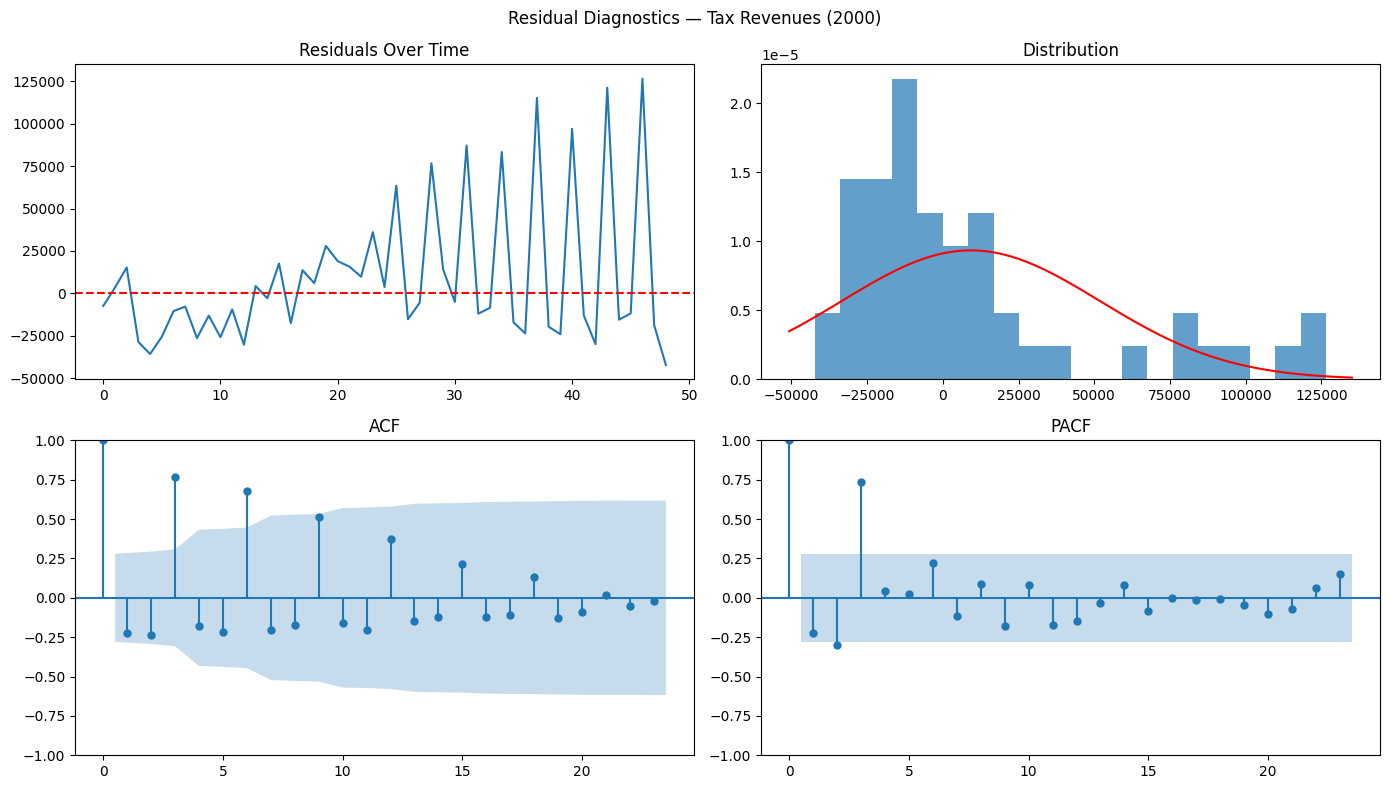

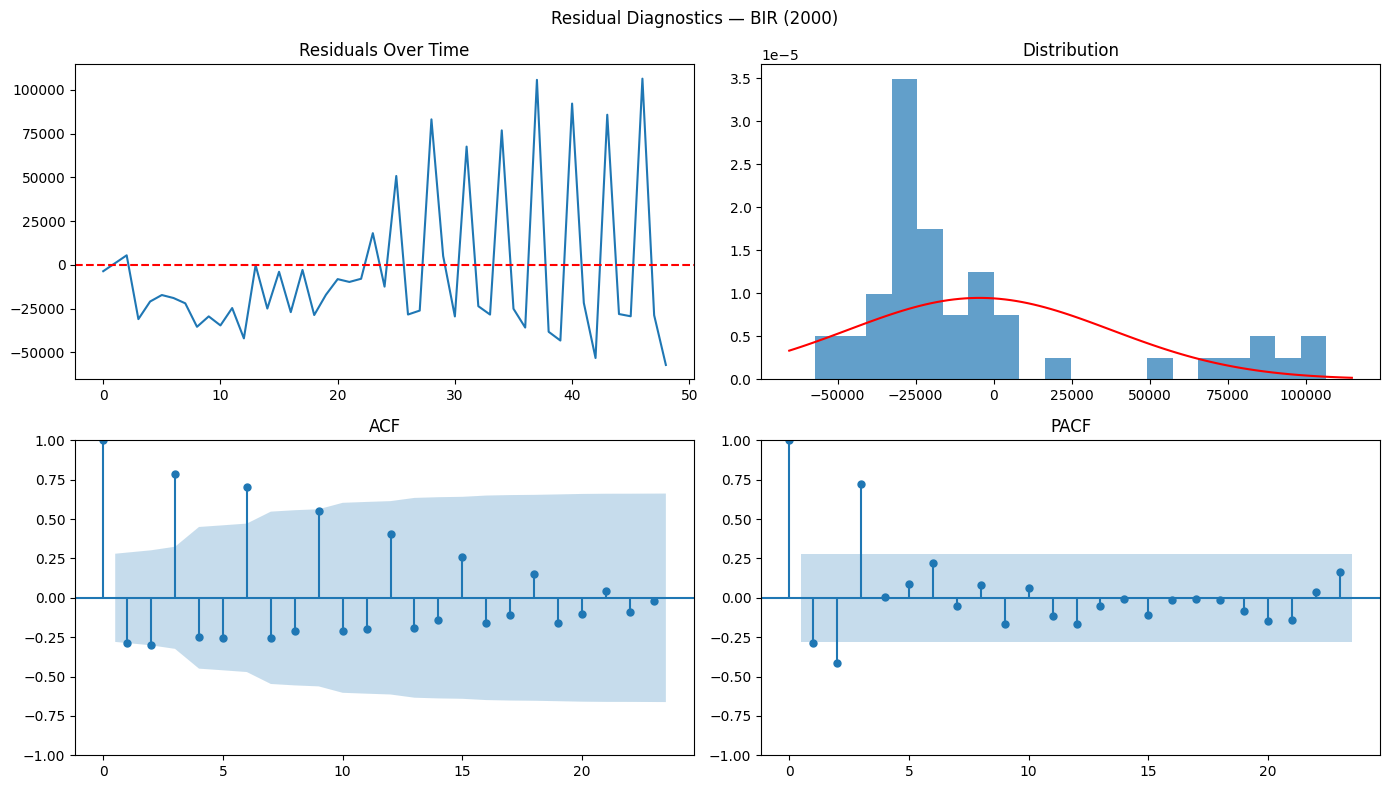

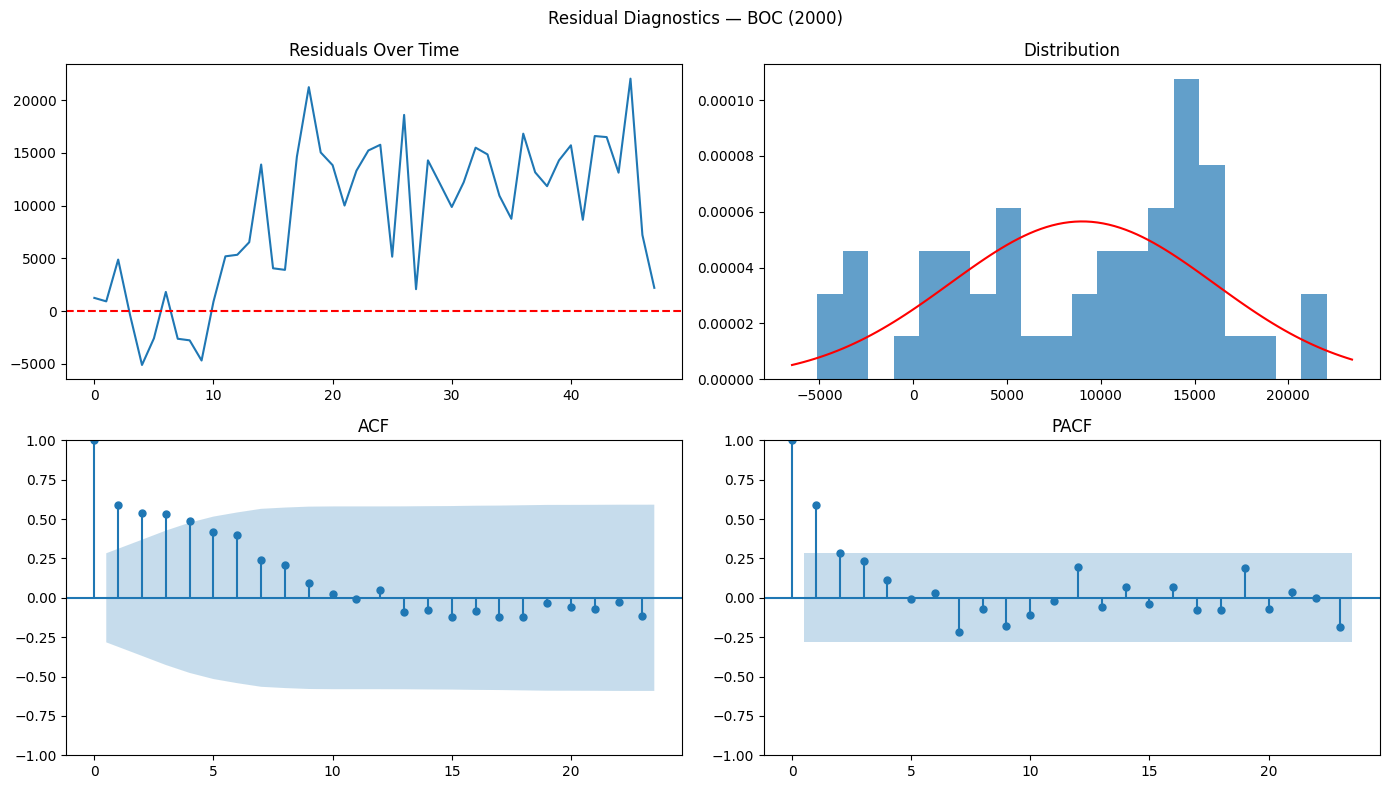

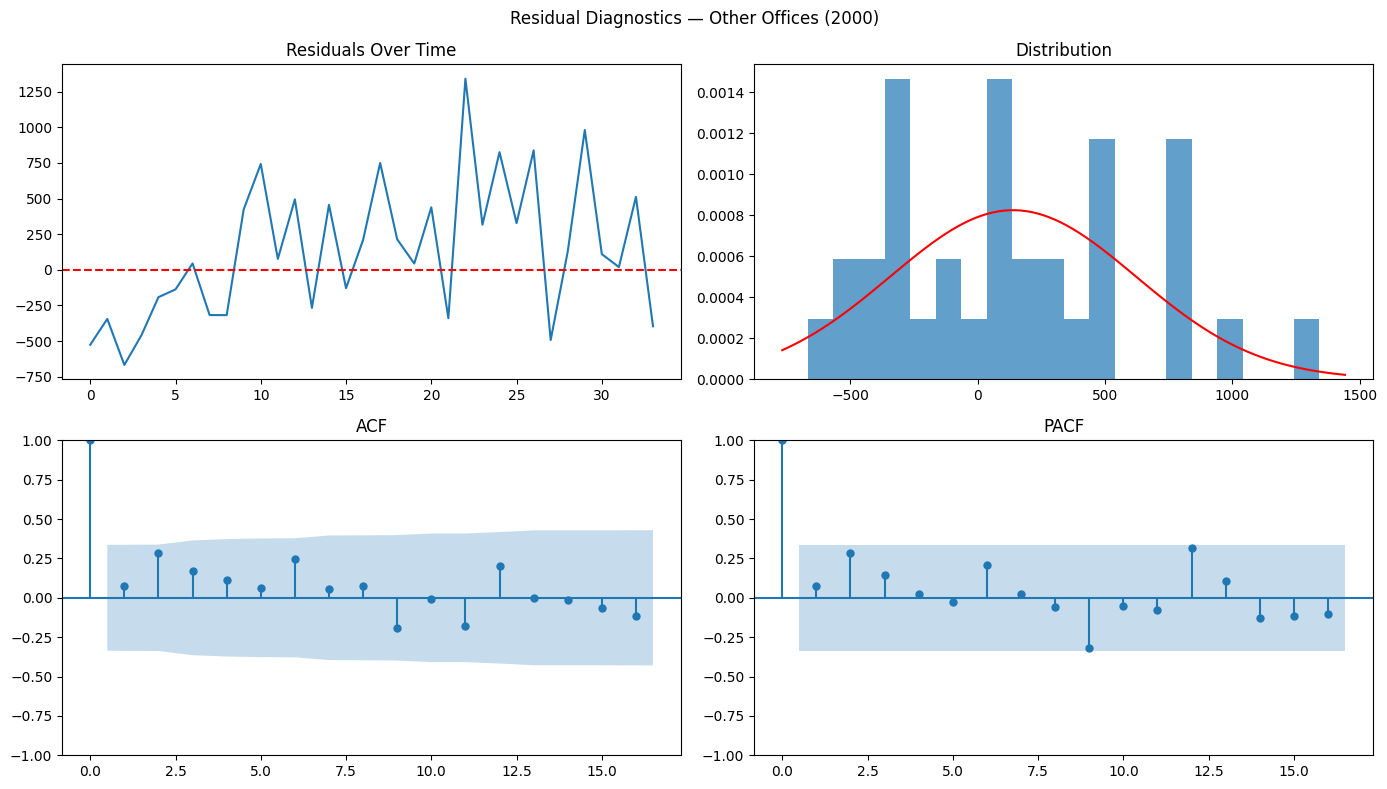

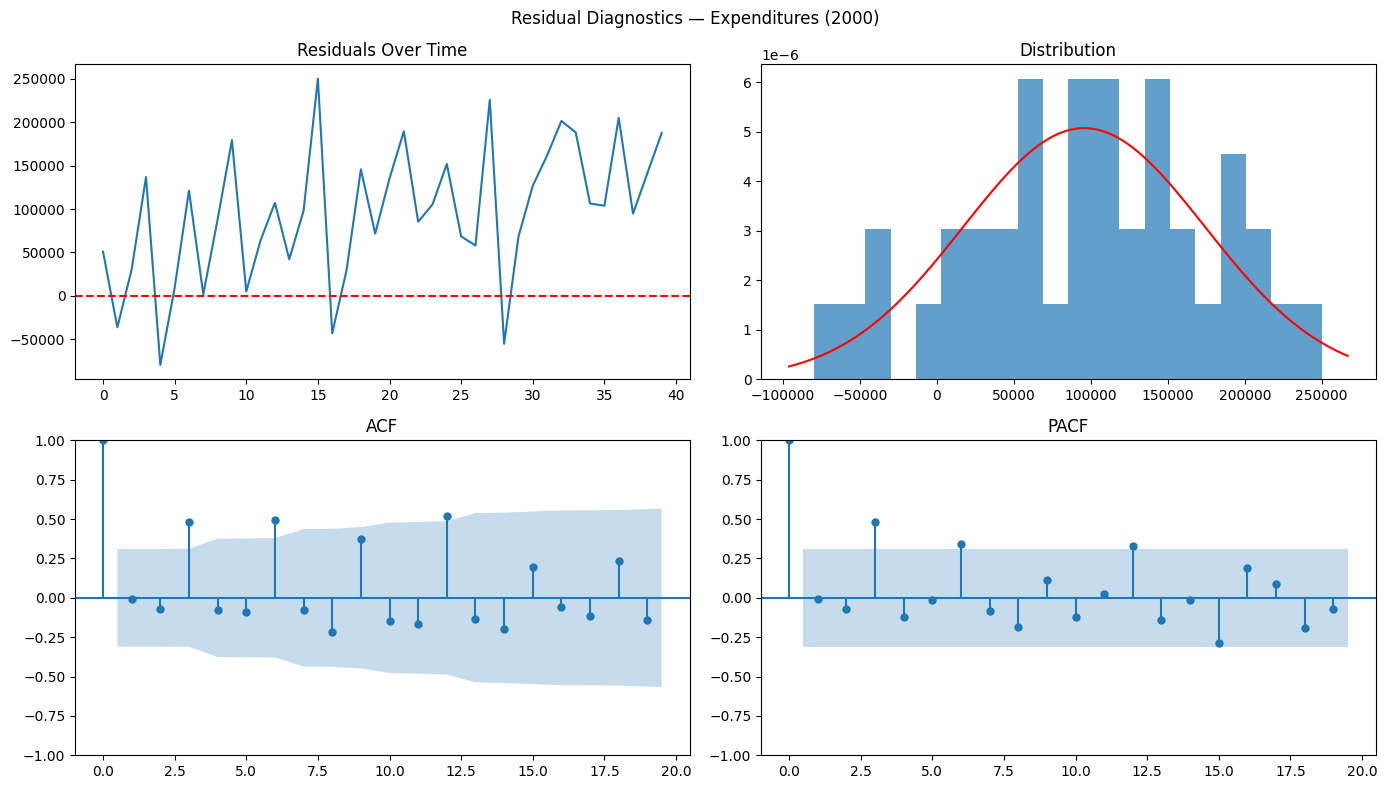

In [29]:
for start_date in START_DATES:
    for label in LABEL_COLS:
        label_slug     = label.replace(' ', '_')
        exp_name       = f"{label_slug}_{start_date[:4]}_feat_select"
        results_folder = f"results/{exp_name}"

        actual    = np.load(f"{results_folder}/test_actuals.npy").flatten()
        preds     = np.load(f"{results_folder}/test_predictions.npy").flatten()
        residuals = actual - preds

        plot_residual_diagnostics(
            actual, preds,
            f"{label} ({start_date[:4]})",
            save_dir=results_folder
        )


In [30]:
SARIMA_GRID = {
    'p_range': range(0, 3),
    'd_range': range(0, 2),
    'q_range': range(0, 3),
    'P_range': (0, 1),
    'D_range': (0, 1),
    'Q_range': (0, 1),
    's_range': (3,6,12),
    'top_n':   5,
    'n_jobs':  max(1, (os.cpu_count() or 2) - 1)
}

sarima_summary = {}

for start_date in START_DATES:
    sarima_summary[start_date] = {}

    for label in LABEL_COLS:
        label_slug = label.replace(' ', '_')
        exp_name   = f"{label_slug}_{start_date[:4]}_feat_select"
        results_folder = f"results/{exp_name}"

        print(f"\n{'='*60}\n  {label} | Start: {start_date[:4]}\n{'='*60}")

        # Load residuals
        train_actuals   = np.load(f"{results_folder}/train_actuals.npy").flatten()
        train_preds_arr = np.load(f"{results_folder}/train_predictions.npy").flatten()
        val_actuals     = np.load(f"{results_folder}/val_actuals.npy").flatten()
        val_preds_arr   = np.load(f"{results_folder}/val_predictions.npy").flatten()
        test_actuals    = np.load(f"{results_folder}/test_actuals.npy").flatten()
        tcn_preds       = np.load(f"{results_folder}/test_predictions.npy").flatten()

        train_residuals = train_actuals - train_preds_arr
        val_residuals   = val_actuals   - val_preds_arr
        fit_residuals   = np.concatenate([train_residuals, val_residuals])
        test_residuals  = test_actuals  - tcn_preds

        # Grid search
        print(f"\n  Grid search... (n_jobs={SARIMA_GRID['n_jobs']})")
        best = sm.gridsearch(train=train_residuals, val=val_residuals, **SARIMA_GRID)
        print(f"\n  Top {SARIMA_GRID['top_n']} by MSE:")
        print(best.to_string(index=False))
        best.to_csv(f"{results_folder}/arima_grid_search.csv", index=False)

        # Final fit
        print("\n  Fitting best model...")
        top = best.iloc[0]
        residual_preds, metrics = sm.fit_sarima(
            fit_residuals, test_residuals,
            order=top['order'],
            seasonal_order=top['seasonal_order'],
        )

        # Hybrid prediction
        hybrid_preds   = tcn_preds + residual_preds
        hybrid_metrics = sm.compute_metrics(test_actuals, hybrid_preds)
        tcn_metrics    = sm.compute_metrics(test_actuals, tcn_preds)

        np.save(f"{results_folder}/arima_residual_predictions.npy", residual_preds)
        np.save(f"{results_folder}/hybrid_predictions.npy",         hybrid_preds)

        sarima_summary[start_date][label] = {
            'order':          list(top['order']),
            'seasonal_order': list(top['seasonal_order']),
            'tcn_mape':       float(tcn_metrics['mape']),
            'tcn_rmse':       float(tcn_metrics['rmse']),
            'hybrid_mape':    float(hybrid_metrics['mape']),
            'hybrid_rmse':    float(hybrid_metrics['rmse']),
        }

with open("results/arima_summary.json", "w") as f:
    json.dump(sarima_summary, f, indent=4)

# ── Summary ───────────────────────────────────────────────
print(f"\n{'='*60}\nFINAL SUMMARY\n{'='*60}")
rows = []
for start_date, labels in sarima_summary.items():
    for label, info in labels.items():
        rows.append({"Start": start_date[:4], "Label": label, "Model": "TCN",    "MAPE": f"{info['tcn_mape']:.4f}%",    "RMSE": f"{info['tcn_rmse']:.2f}"})
        rows.append({"Start": start_date[:4], "Label": label, "Model": "Hybrid", "MAPE": f"{info['hybrid_mape']:.4f}%", "RMSE": f"{info['hybrid_rmse']:.2f}"})

print(pd.DataFrame(rows).to_string(index=False))


  Tax Revenues | Start: 2000

  Grid search... (n_jobs=21)
  Fitting 432 models (seasonal)...

  Top 5 by MSE:
    order seasonal_order          MSE
(0, 0, 0)   (0, 0, 0, 6) 1.400227e+08
(0, 0, 0)  (0, 0, 0, 12) 1.400227e+08
(0, 0, 0)   (0, 0, 0, 3) 1.400227e+08
(0, 0, 0)   (0, 0, 1, 6) 1.984560e+08
(0, 0, 0)   (0, 0, 1, 3) 2.154575e+08

  Fitting best model...

  BIR | Start: 2000

  Grid search... (n_jobs=21)
  Fitting 432 models (seasonal)...

  Top 5 by MSE:
    order seasonal_order          MSE
(0, 0, 0)  (0, 0, 0, 12) 1.484629e+08
(0, 0, 0)   (0, 0, 0, 6) 1.484629e+08
(0, 0, 0)   (0, 0, 0, 3) 1.484629e+08
(0, 0, 0)   (0, 0, 1, 6) 1.670691e+08
(0, 0, 0)   (0, 0, 1, 3) 1.696915e+08

  Fitting best model...

  BOC | Start: 2000

  Grid search... (n_jobs=21)
  Fitting 432 models (seasonal)...

  Top 5 by MSE:
    order seasonal_order          MSE
(0, 0, 2)   (0, 0, 1, 3) 1.518915e+07
(0, 0, 0)  (0, 0, 0, 12) 1.527375e+07
(0, 0, 0)   (0, 0, 0, 6) 1.527375e+07
(0, 0, 0)   (0, 0, 0, 3)

In [31]:
def plot_test_predictions(test_preds, test_actuals, label, save_dir=None):
    test_preds   = np.array(test_preds).flatten()
    test_actuals = np.array(test_actuals).flatten()

    plt.figure(figsize=(12, 6))
    plt.plot(test_actuals, label='Actual',    linewidth=2)
    plt.plot(test_preds,   label='Predicted', linewidth=2, alpha=0.7)
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.title(f'{label}: Predictions vs Actual')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/predictions.png", dpi=150)
    plt.show()

def plot_qq(actual_dict, pred_dict, label_cols, save_path=None):
    fig, axes = plt.subplots(1, len(label_cols), figsize=(5 * len(label_cols), 4))
    if len(label_cols) == 1:
        axes = [axes]

    for ax, label in zip(axes, label_cols):
        residuals = np.array(actual_dict[label]).flatten() - np.array(pred_dict[label]).flatten()
        stats.probplot(residuals, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot — {label}')
        ax.get_lines()[1].set_color('red')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


  PLOTTING: Tax Revenues | Start: 2000


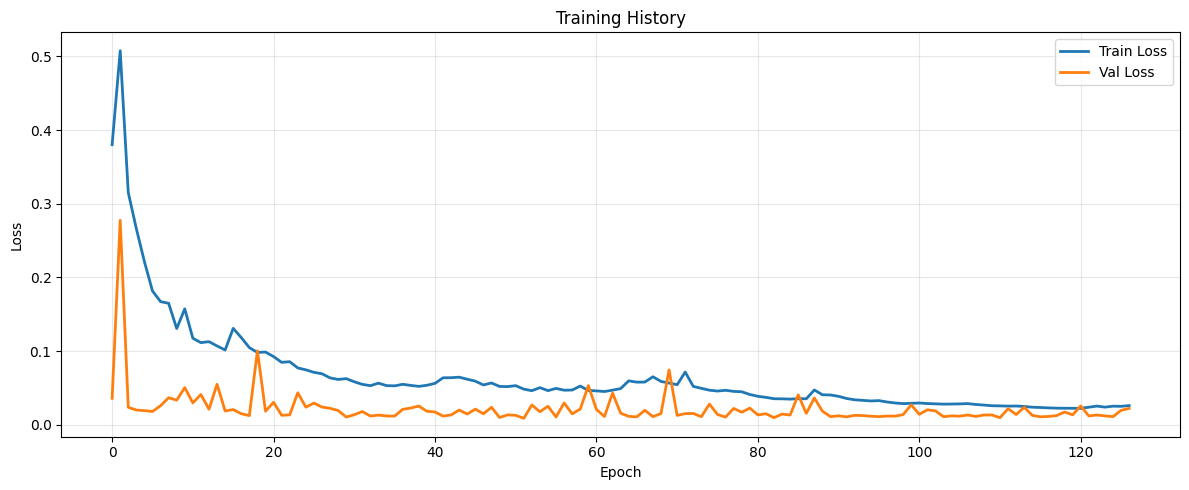

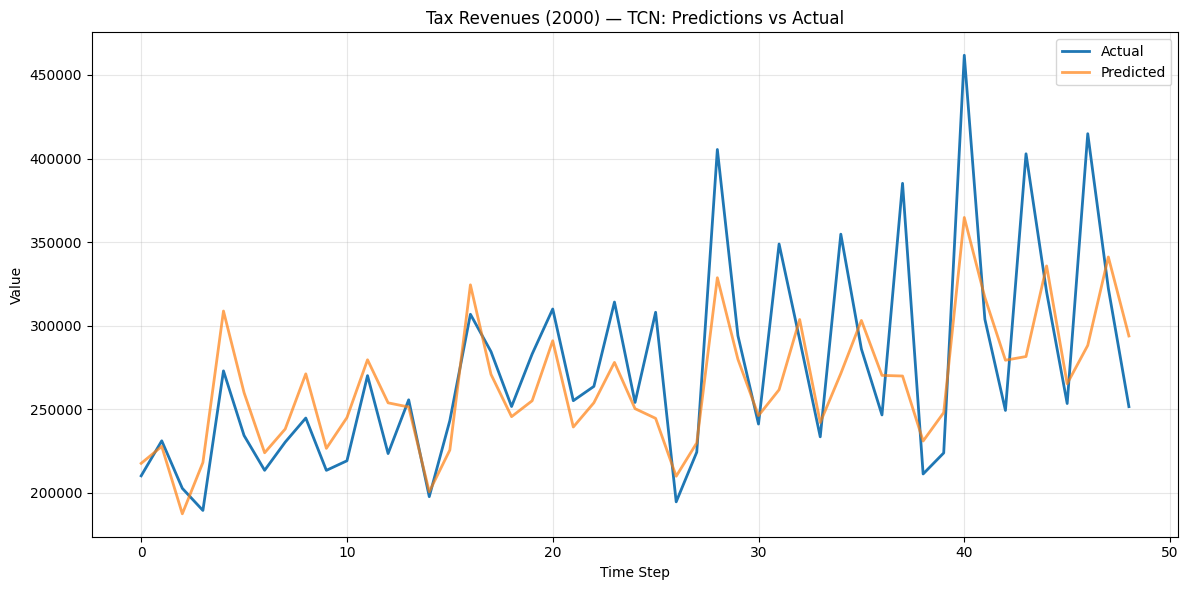

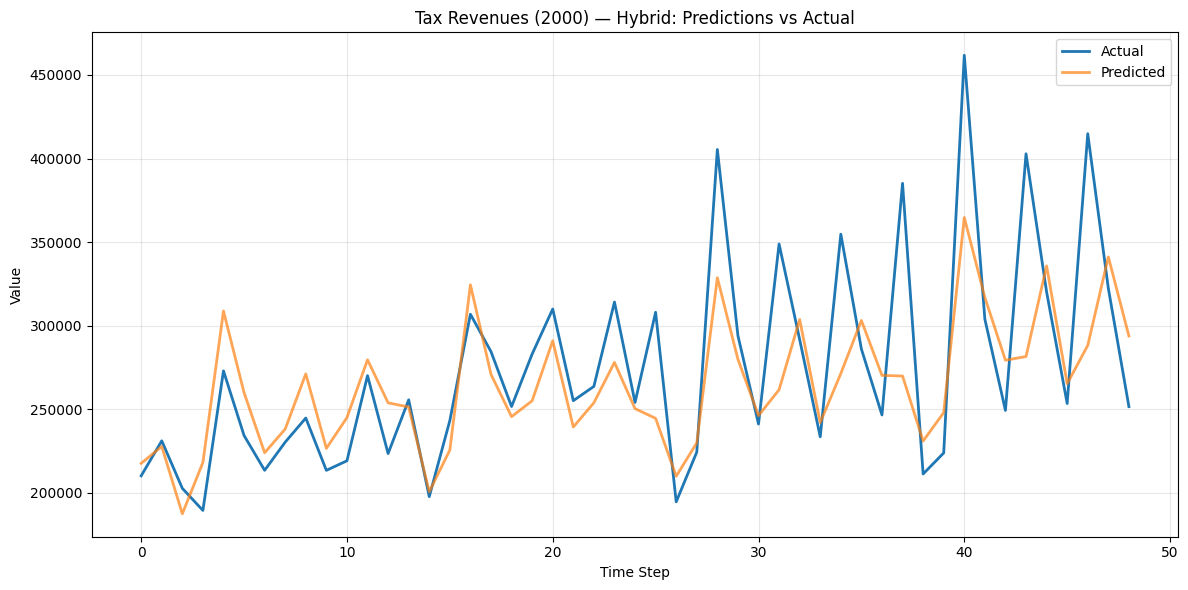

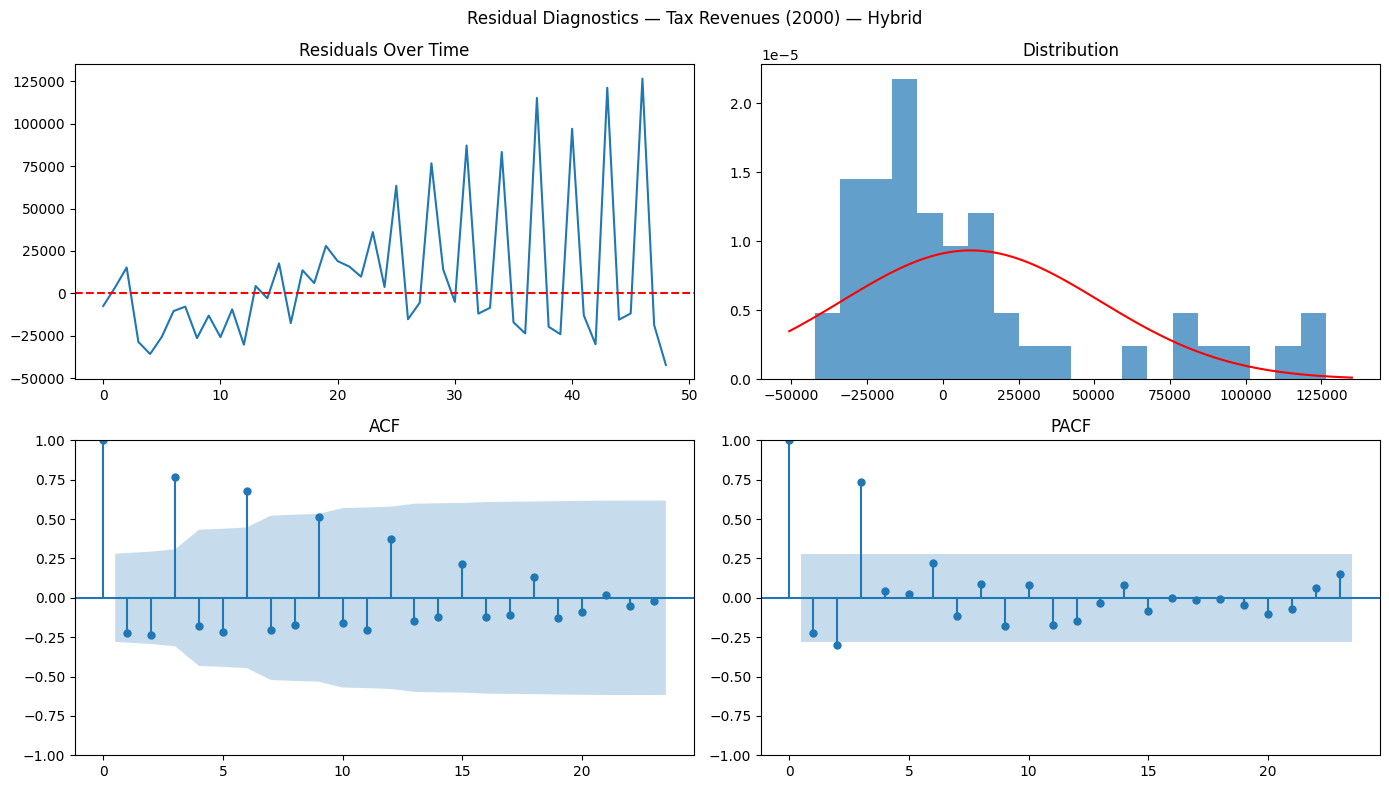

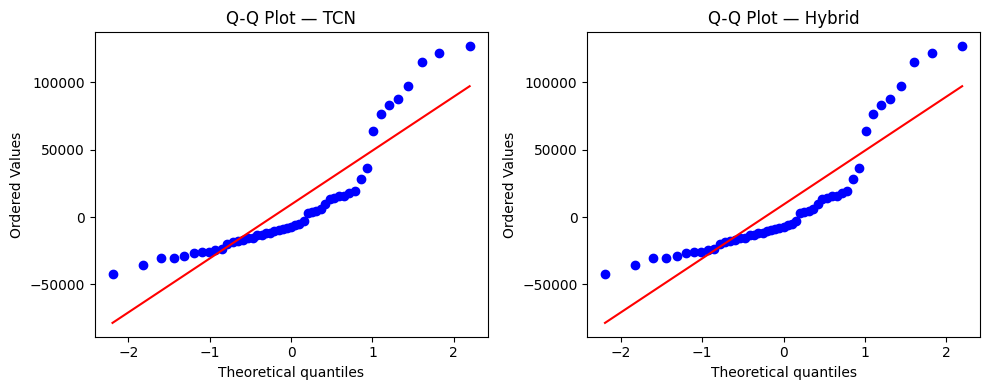


  PLOTTING: BIR | Start: 2000


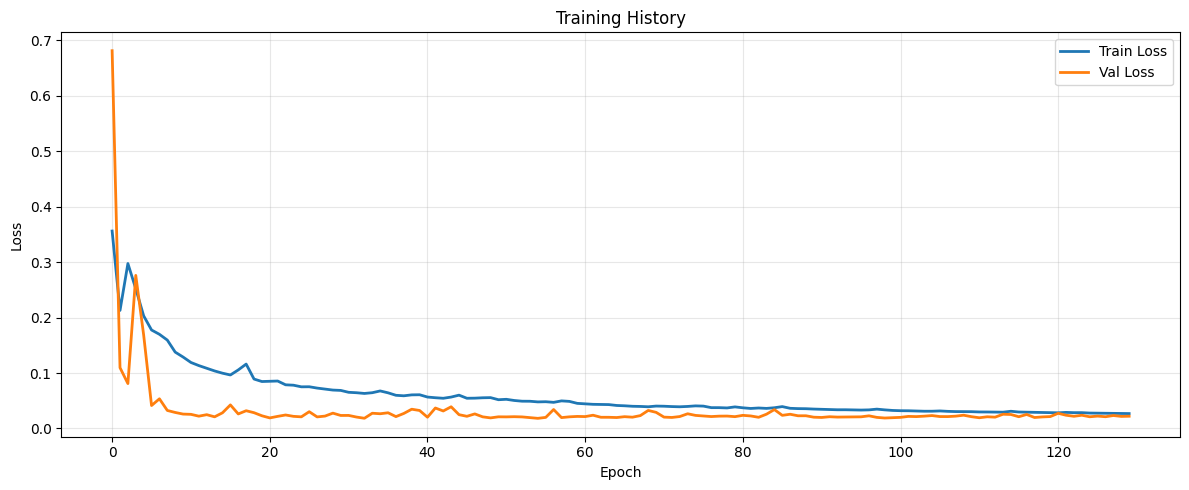

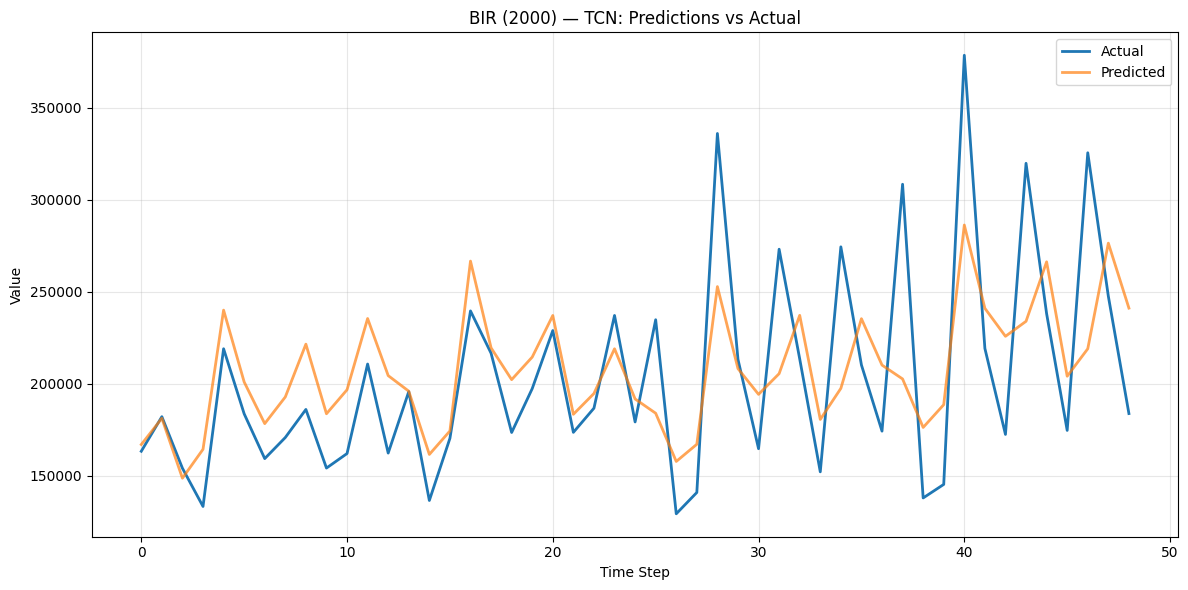

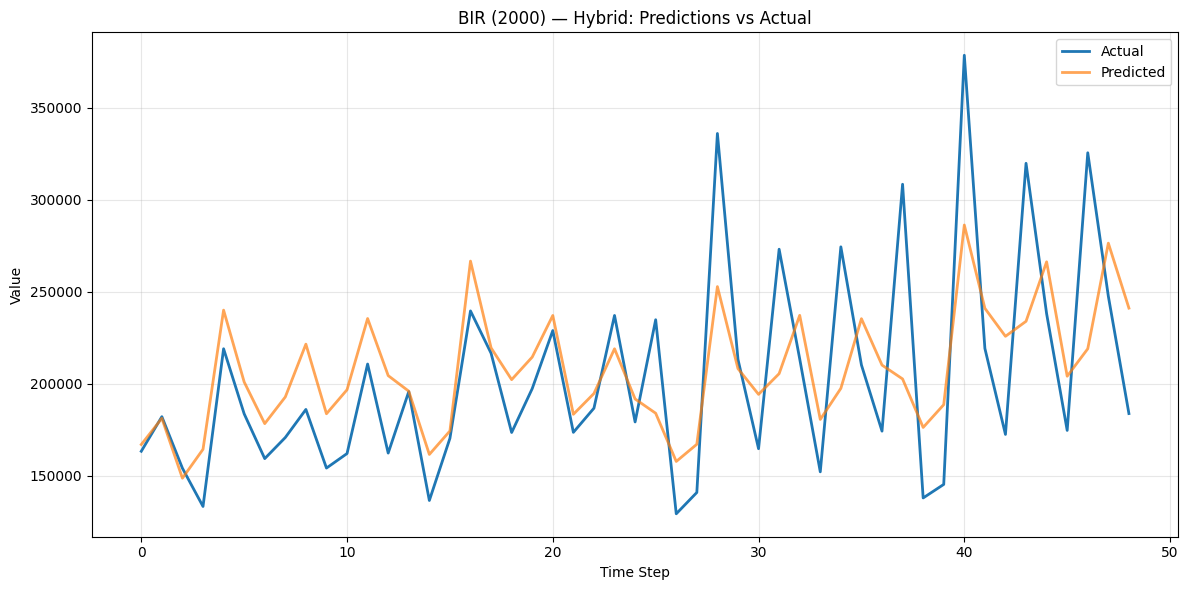

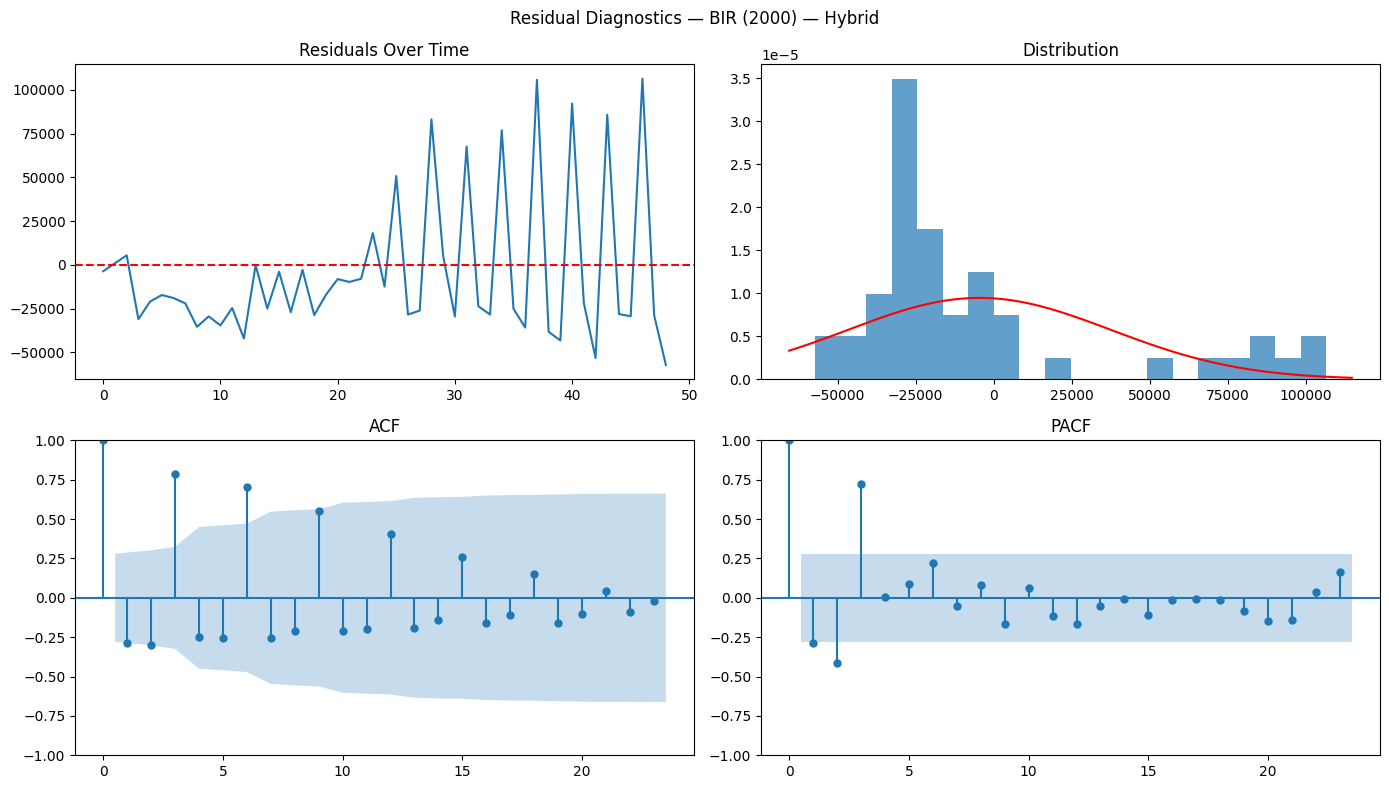

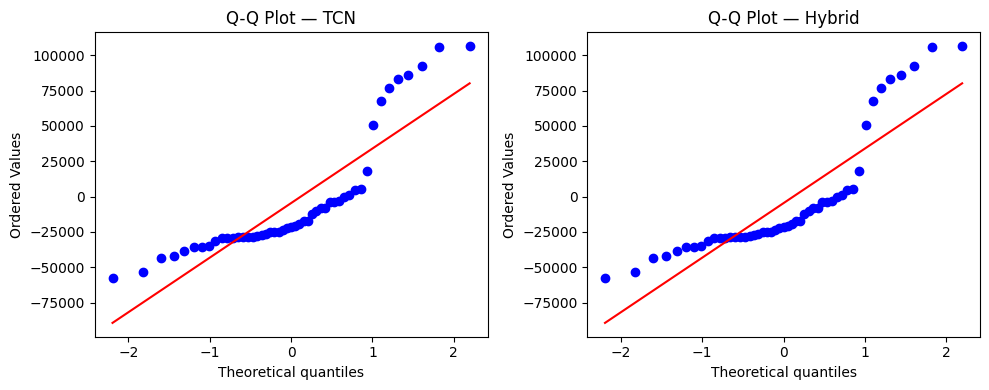


  PLOTTING: BOC | Start: 2000


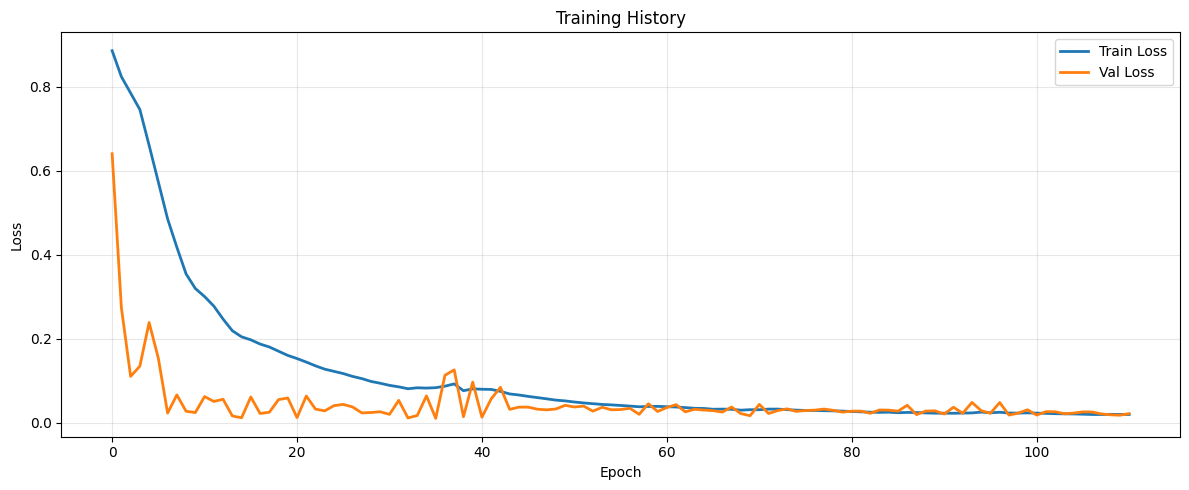

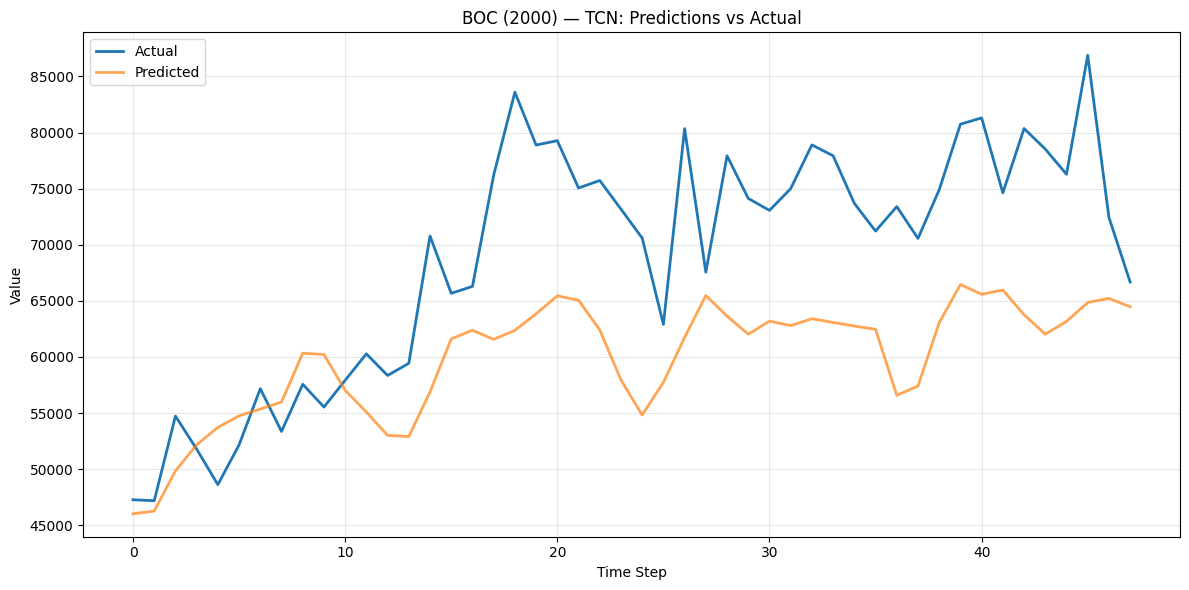

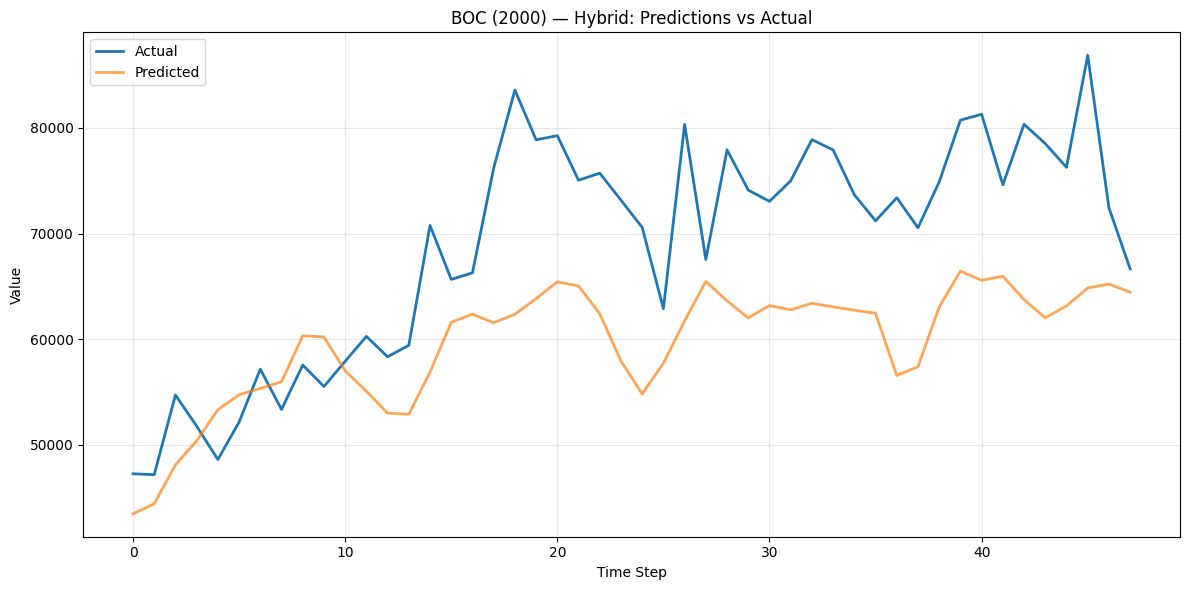

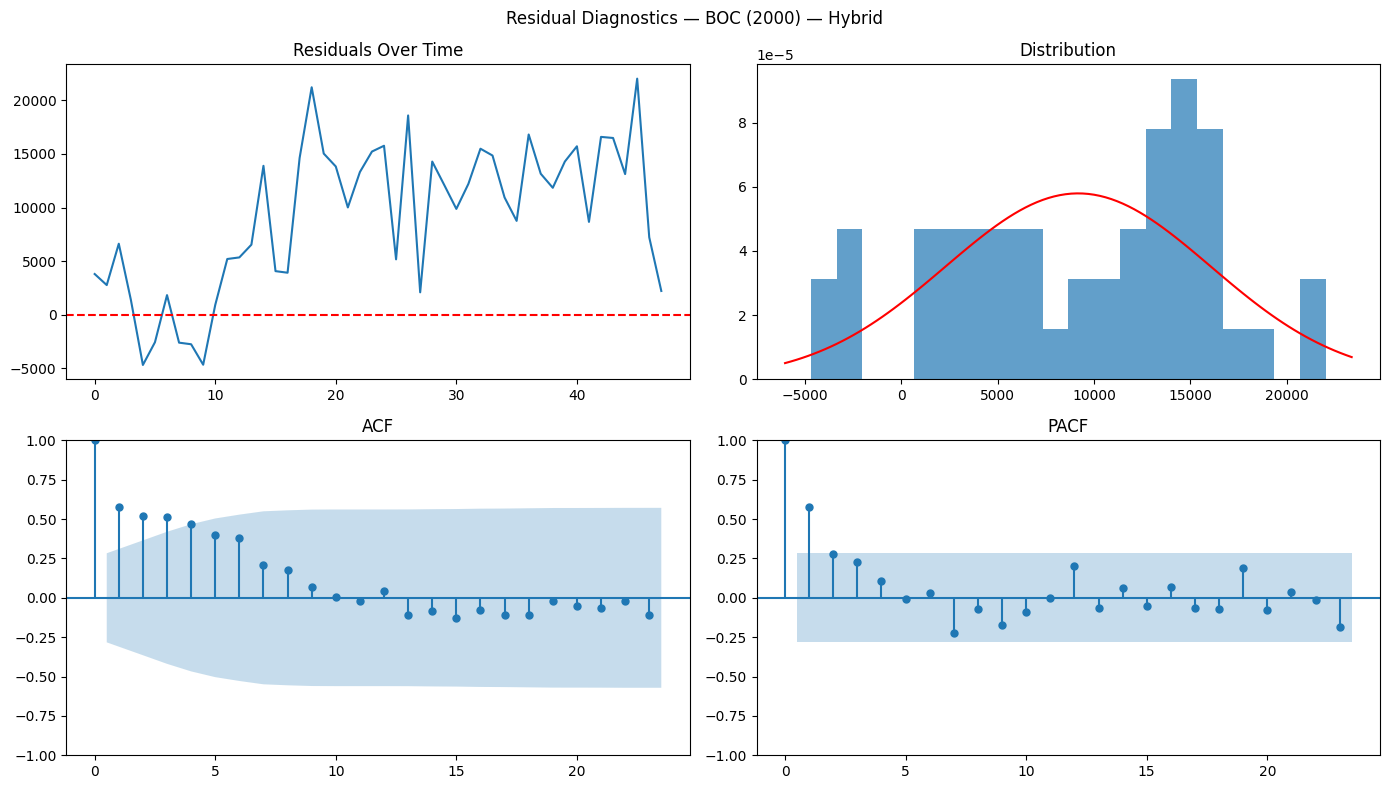

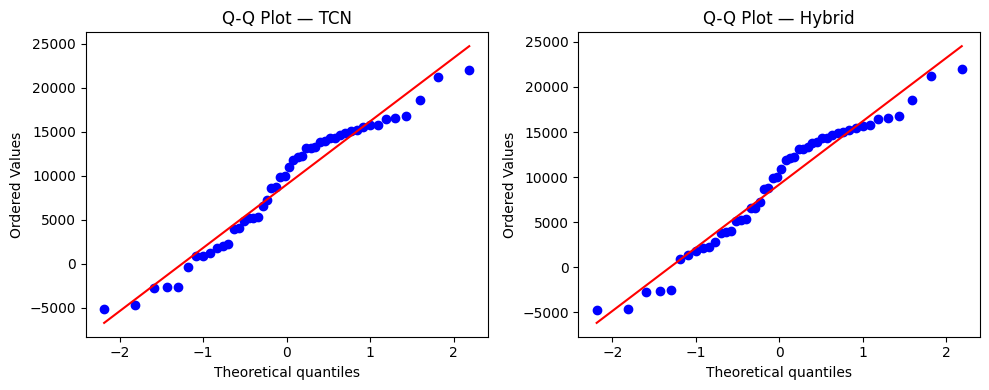


  PLOTTING: Other Offices | Start: 2000


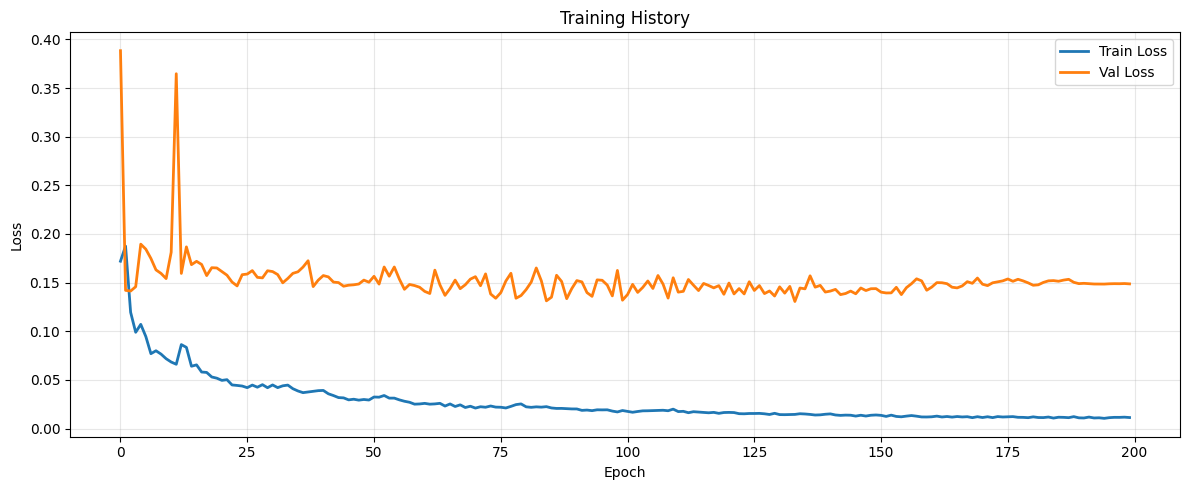

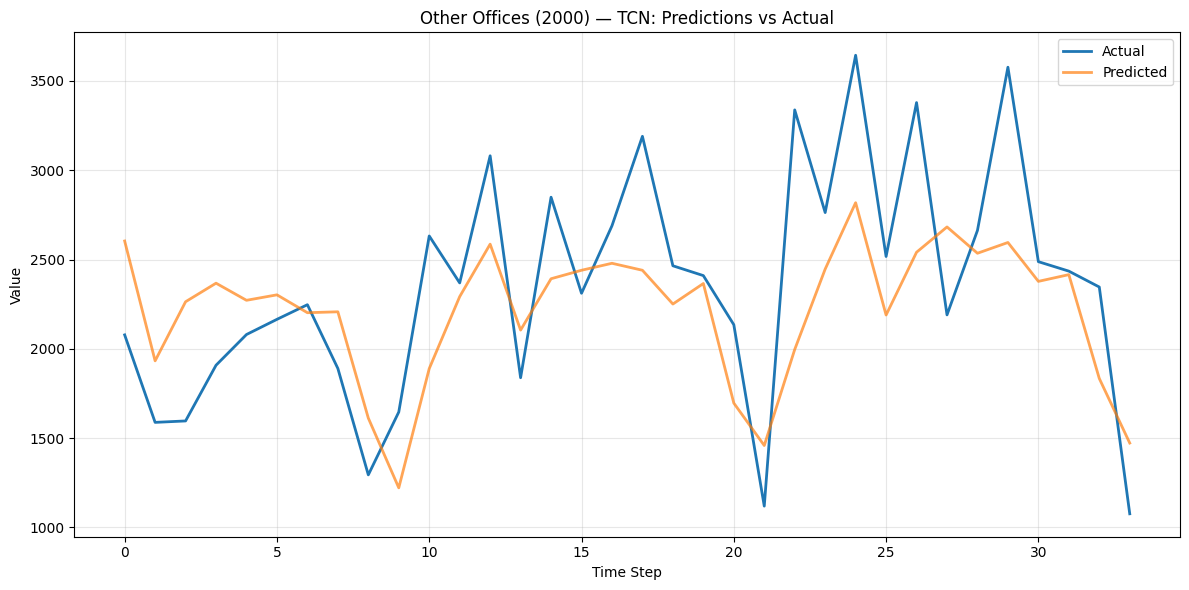

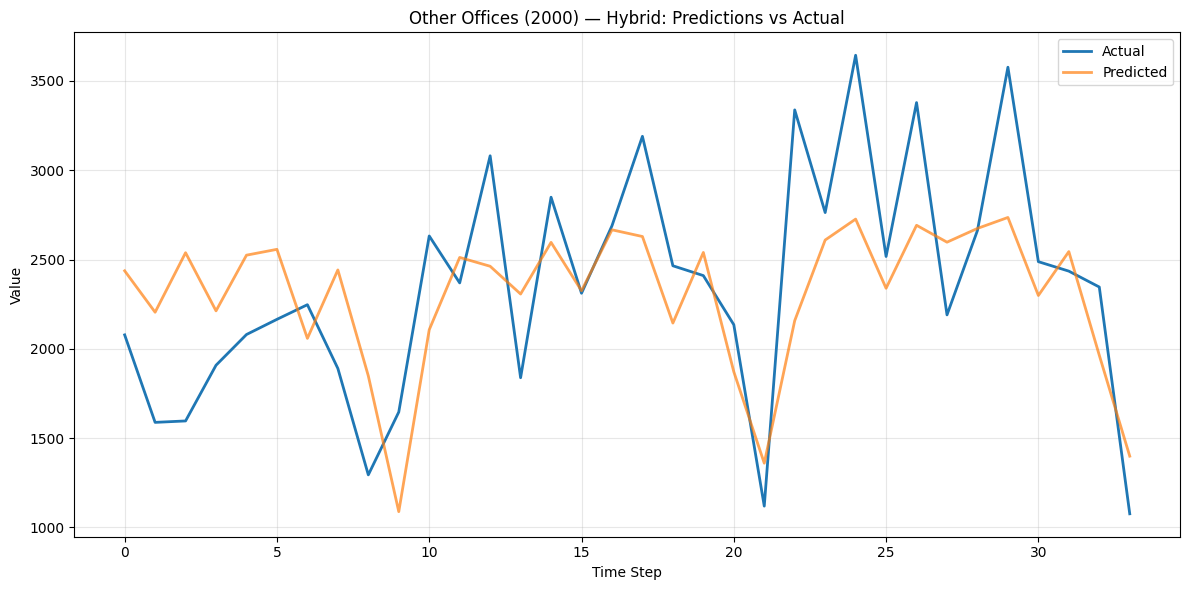

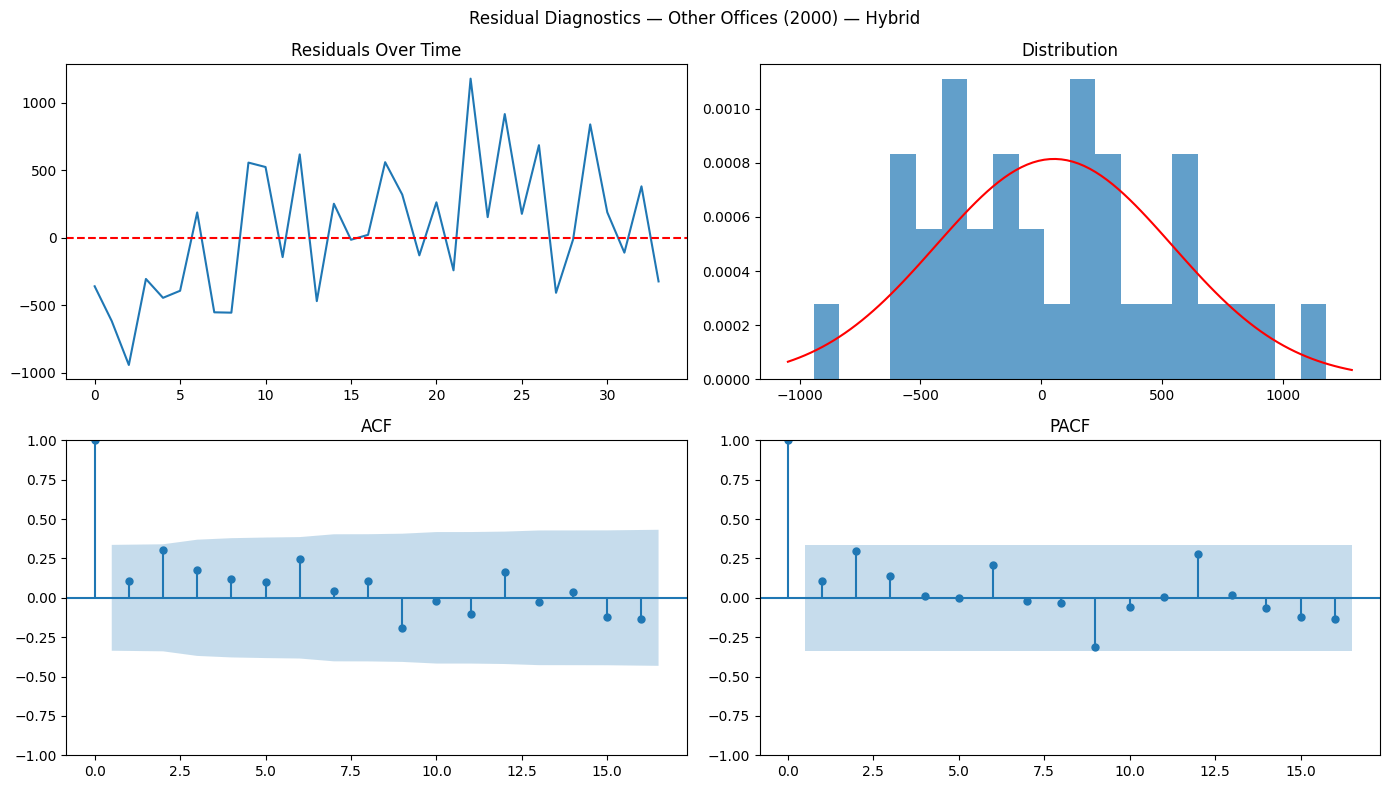

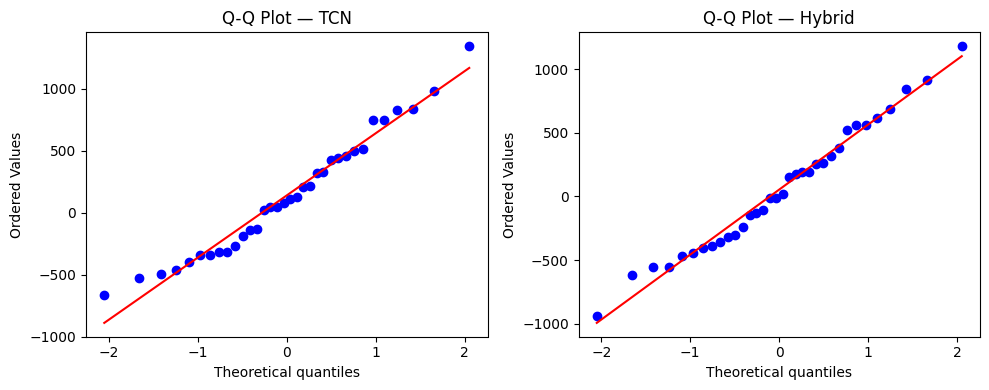


  PLOTTING: Expenditures | Start: 2000


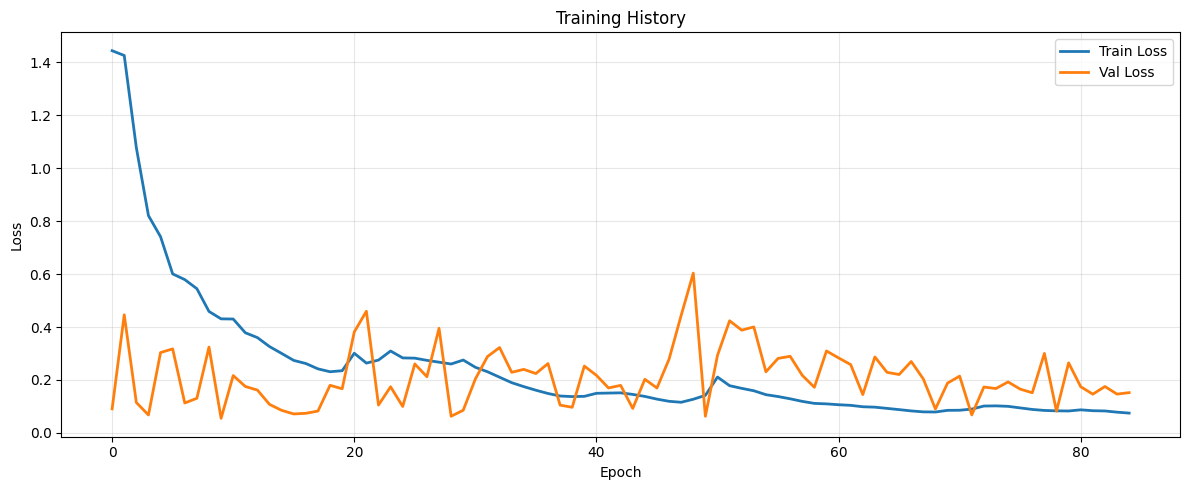

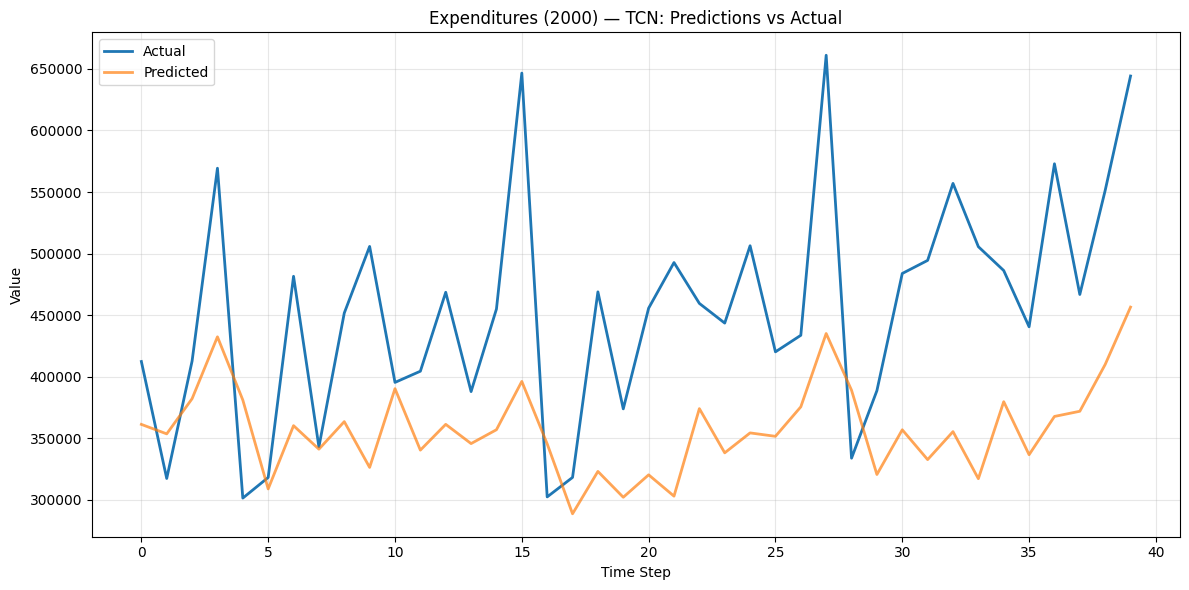

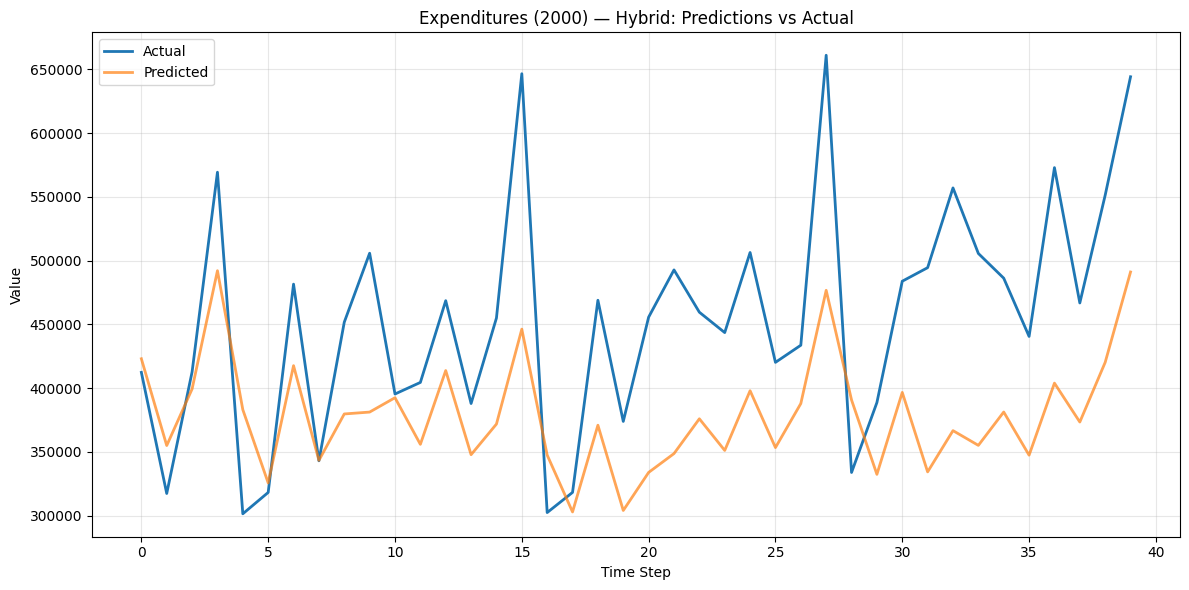

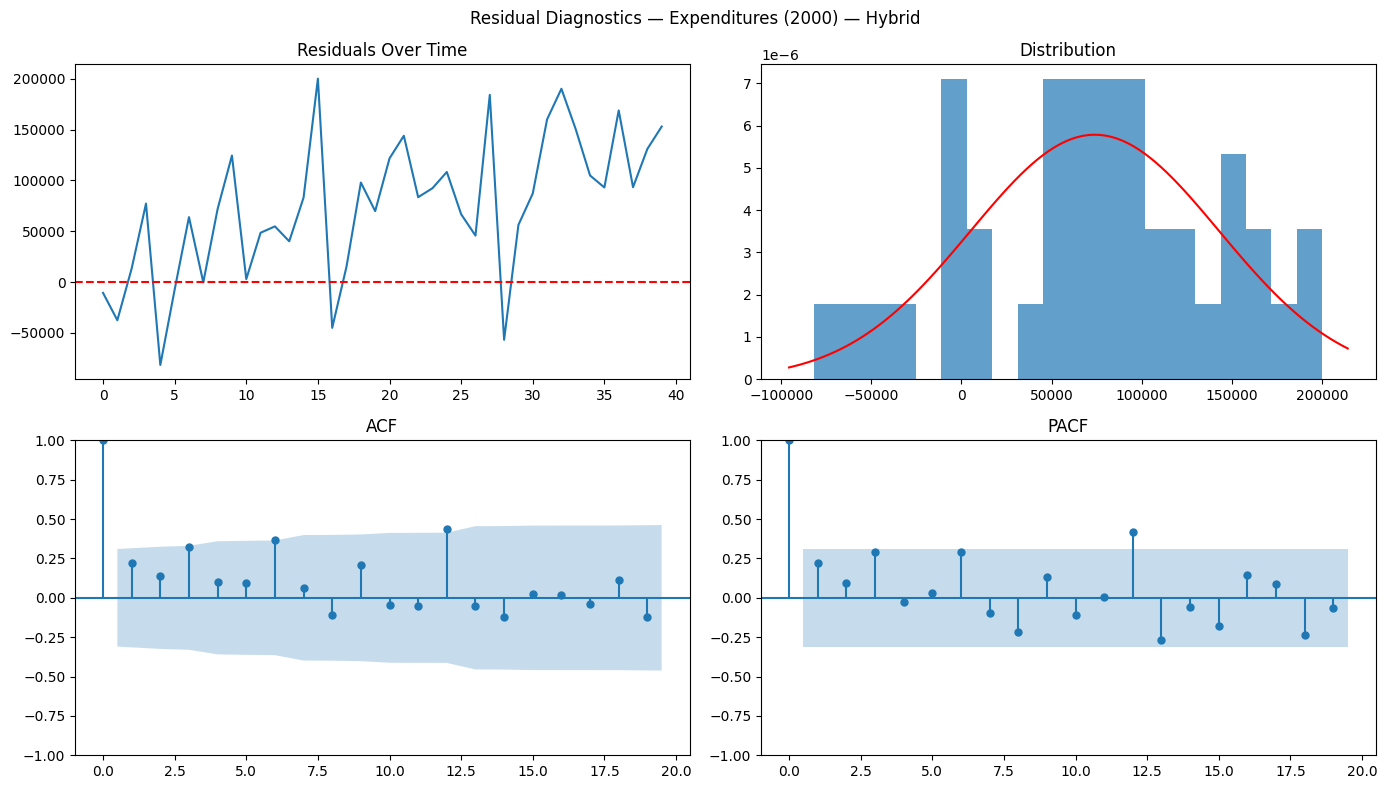

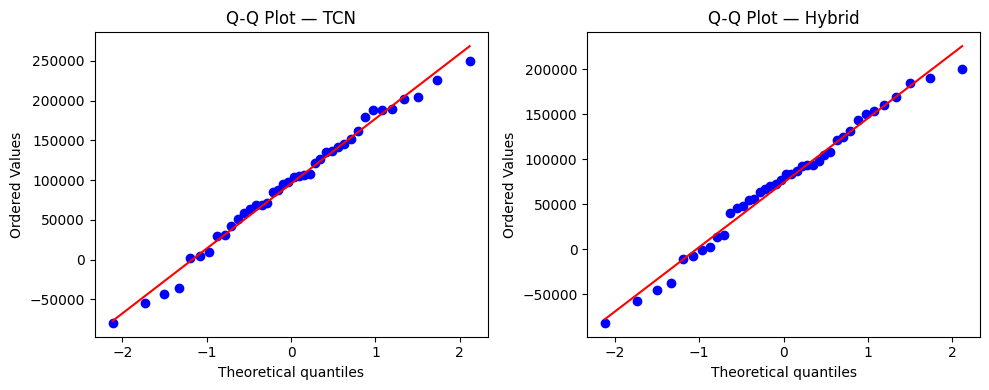

In [32]:
for start_date in START_DATES:
    for label in LABEL_COLS:
        label_slug     = label.replace(' ', '_')
        exp_name       = f"{label_slug}_{start_date[:4]}_feat_select"
        results_folder = f"results/{exp_name}"
        config_folder  = f"configs/{exp_name}"

        print(f"\n{'='*60}\n  PLOTTING: {label} | Start: {start_date[:4]}\n{'='*60}")

        # Load
        test_preds   = np.load(f"{results_folder}/test_predictions.npy")
        test_actuals = np.load(f"{results_folder}/test_actuals.npy")
        hybrid_preds = np.load(f"{results_folder}/hybrid_predictions.npy")
        train_losses = np.load(f"{results_folder}/train_losses.npy")
        val_losses   = np.load(f"{results_folder}/val_losses.npy")

        # Training history
        utils.plot_training_history(train_losses, val_losses)

        # Predictions vs actuals
        plot_test_predictions(test_preds,   test_actuals, f"{label} ({start_date[:4]}) — TCN",    save_dir=results_folder)
        plot_test_predictions(hybrid_preds, test_actuals, f"{label} ({start_date[:4]}) — Hybrid", save_dir=results_folder)

        # Residual diagnostics
        plot_residual_diagnostics(test_actuals, hybrid_preds, f"{label} ({start_date[:4]}) — Hybrid", save_dir=results_folder)

        # QQ
        plot_qq(
            {'TCN': test_actuals, 'Hybrid': test_actuals},
            {'TCN': test_preds,   'Hybrid': hybrid_preds},
            ['TCN', 'Hybrid'],
            save_path=f"{results_folder}/qq_plots.png"
        )

### SHAP

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from data import inverse_transform
import shap
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_residual_diagnostics(actual, pred, label, save_dir=None):
    actual    = np.array(actual).flatten()
    pred      = np.array(pred).flatten()
    residuals = actual - pred
    max_lags  = min(24, len(residuals) // 2 - 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Residual Diagnostics — {label}')

    # Residuals over time
    axes[0,0].plot(residuals)
    axes[0,0].axhline(0, color='red', linestyle='--')
    axes[0,0].set_title('Residuals Over Time')

    # Distribution
    axes[0,1].hist(residuals, bins=20, density=True, alpha=0.7)
    xmin, xmax = axes[0,1].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    axes[0,1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r')
    axes[0,1].set_title('Distribution')

    # ACF / PACF
    plot_acf(residuals,  lags=max_lags, ax=axes[1,0], title='ACF')
    plot_pacf(residuals, lags=max_lags, ax=axes[1,1], title='PACF')

    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/residual_diagnostics.png", dpi=150)
    plt.show()


def plot_qq(actual_dict, pred_dict, label_cols, save_path=None):
    fig, axes = plt.subplots(1, len(label_cols), figsize=(5 * len(label_cols), 4))
    if len(label_cols) == 1:
        axes = [axes]

    for ax, label in zip(axes, label_cols):
        residuals = np.array(actual_dict[label]).flatten() - np.array(pred_dict[label]).flatten()
        stats.probplot(residuals, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot — {label}')
        ax.get_lines()[1].set_color('red')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

def plot_training_history(train_losses, val_losses):
    plt.figure(figsize=(12, 5))
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Val Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_test_predictions(test_preds, test_actuals, label, save_dir=None):
    test_preds   = np.array(test_preds).flatten()
    test_actuals = np.array(test_actuals).flatten()

    plt.figure(figsize=(12, 6))
    plt.plot(test_actuals, label='Actual',    linewidth=2)
    plt.plot(test_preds,   label='Predicted', linewidth=2, alpha=0.7)
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.title(f'{label}: Predictions vs Actual')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/predictions.png", dpi=150)
    plt.show()

def explain_model(models, data_loader, args, num_samples=100):
    """Generate SHAP explanations for TCN using full sequence inputs."""
    for m in models:
        m.eval()

    # Build base feature names from args
    base_feature_names = []
    if hasattr(args, 'features'):
        base_feature_names.extend(args.features)
    if hasattr(args, 'labels') and hasattr(args, 'lag_periods'):
        for label in args.labels:
            for lag in args.lag_periods:
                base_feature_names.append(f'{label}_lag_{lag}')
    if hasattr(args, 'dummy_vars'):
        base_feature_names.extend(args.dummy_vars)
    if getattr(args, 'use_seasonal', False):
        base_feature_names.extend(['month_sin', 'month_cos', 'quarter_sin', 'quarter_cos',
                                   'is_tax_season', 'is_year_end'])

    # Collect full sequence tensors and flatten for SHAP
    background_data = None
    test_batches = []
    n_features = None
    seq_len = None
    for i, (inputs, _) in enumerate(data_loader):
        arr = inputs.cpu().numpy()  # [batch, features, seq_len]
        if n_features is None:
            n_features, seq_len = arr.shape[1], arr.shape[2]
        flat = arr.reshape(arr.shape[0], -1)
        if background_data is None:
            background_data = flat[:num_samples]
        test_batches.append(flat)
        if sum(b.shape[0] for b in test_batches) >= 20:
            break
    test_data = np.vstack(test_batches)[:20]

    # Ensure feature-name count matches flattened input width
    if not base_feature_names or len(base_feature_names) != n_features:
        base_feature_names = [f'feature_{i}' for i in range(n_features)]
    feature_names = []
    for fname in base_feature_names:
        for t in range(seq_len):
            feature_names.append(f'{fname}_t{t}')

    # prediction wrapper
    def model_predict(x):
        x_tensor = torch.FloatTensor(x).to(args.device).reshape(-1, n_features, seq_len)
        preds = []
        with torch.no_grad():
            for m in models:
                preds.append(m(x_tensor).cpu().numpy())
        return np.mean(preds, axis=0)

    explainer = shap.KernelExplainer(model_predict, background_data)
    shap_values = explainer.shap_values(test_data, nsamples=100)

    return explainer, shap_values, test_data, feature_names


def plot_shap_summary(shap_values, test_data, feature_names, output_name=None):
    """Plot SHAP summary - shows feature importance."""
    title = f'SHAP Feature Importance - {output_name}' if output_name else 'SHAP Feature Importance'
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, test_data, feature_names=feature_names, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_shap_bar(shap_values, test_data, feature_names, output_name=None):
    """Plot SHAP bar chart - mean absolute SHAP values."""
    title = f'SHAP Mean Importance - {output_name}' if output_name else 'SHAP Mean Importance'
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, test_data, feature_names=feature_names, plot_type="bar", show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_shap_waterfall(explainer, shap_values, test_data, feature_names, sample_idx=0, output_name=None):
    """Plot SHAP waterfall - explains a single prediction."""
    explanation = shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=test_data[sample_idx],
        feature_names=feature_names,
    )
    title = f'SHAP Waterfall - Sample {sample_idx}, {output_name}' if output_name else f'SHAP Waterfall - Sample {sample_idx}'
    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(explanation, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_shap_dependence(shap_values, test_data, feature_names, feature_idx, output_name=None):
    """Plot SHAP dependence plot for a specific feature."""
    feature_name = feature_names[feature_idx]
    title = f'SHAP Dependence: {feature_name} - {output_name}' if output_name else f'SHAP Dependence: {feature_name}'
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(feature_idx, shap_values, test_data, feature_names=feature_names, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show() 

In [34]:
def explain_model(models, data_loader, args, num_samples=100):
    """Generate SHAP explanations for TCN using full sequence inputs."""
    for m in models:
        m.eval()

    base_feature_names = []
    if hasattr(args, 'features'):
        base_feature_names.extend(args.features)
    if hasattr(args, 'labels') and hasattr(args, 'lag_periods'):
        for label in args.labels:
            for lag in args.lag_periods:
                base_feature_names.append(f'{label}_lag_{lag}')
    if hasattr(args, 'dummy_vars'):
        base_feature_names.extend(args.dummy_vars)
    if getattr(args, 'use_seasonal', False):
        base_feature_names.extend([
            'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos',
            'is_tax_season', 'is_year_end'
        ])

    background_data = None
    test_batches = []
    n_features = None
    seq_len = None

    for i, (inputs, _) in enumerate(data_loader):
        arr = inputs.cpu().numpy()  # [batch, features, seq_len]
        if n_features is None:
            n_features, seq_len = arr.shape[1], arr.shape[2]
        flat = arr.reshape(arr.shape[0], -1)
        if background_data is None:
            background_data = flat[:num_samples]
        test_batches.append(flat)
        if sum(b.shape[0] for b in test_batches) >= 20:
            break

    test_data = np.vstack(test_batches)[:20]

    if not base_feature_names or len(base_feature_names) != n_features:
        base_feature_names = [f'feature_{i}' for i in range(n_features)]

    feature_names = []
    for fname in base_feature_names:
        for t in range(seq_len):
            feature_names.append(f'{fname}_t{t}')

    def model_predict(x):
        x_tensor = torch.FloatTensor(x).to(args.device).reshape(-1, n_features, seq_len)
        preds = []
        with torch.no_grad():
            for m in models:
                preds.append(m(x_tensor).cpu().numpy())
        return np.mean(preds, axis=0)

    explainer = shap.KernelExplainer(model_predict, background_data)
    shap_values = explainer.shap_values(test_data, nsamples=100)

    return explainer, shap_values, test_data, feature_names

In [35]:
def plot_shap_waterfall(explainer, shap_values, test_data, feature_names, sample_idx=0, output_name=None):
    """Plot SHAP waterfall for one sample, robust to SHAP output shapes."""
    sv = shap_values
    if isinstance(sv, list):
        sv = sv[0]

    sv = np.asarray(sv)
    row = np.asarray(sv[sample_idx]).squeeze()

    if row.ndim != 1:
        row = row.reshape(-1)

    base_val = np.asarray(explainer.expected_value).squeeze()
    if np.ndim(base_val) > 0:
        base_val = float(np.ravel(base_val)[0])
    else:
        base_val = float(base_val)

    sample_data = np.asarray(test_data[sample_idx]).reshape(-1)

    explanation = shap.Explanation(
        values=row,
        base_values=base_val,
        data=sample_data,
        feature_names=feature_names,
    )

    title = (
        f"SHAP Waterfall - Sample {sample_idx}, {output_name}"
        if output_name else f"SHAP Waterfall - Sample {sample_idx}"
    )
    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(explanation, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

  Loaded 10 seed models


100%|██████████| 20/20 [02:14<00:00,  6.73s/it]


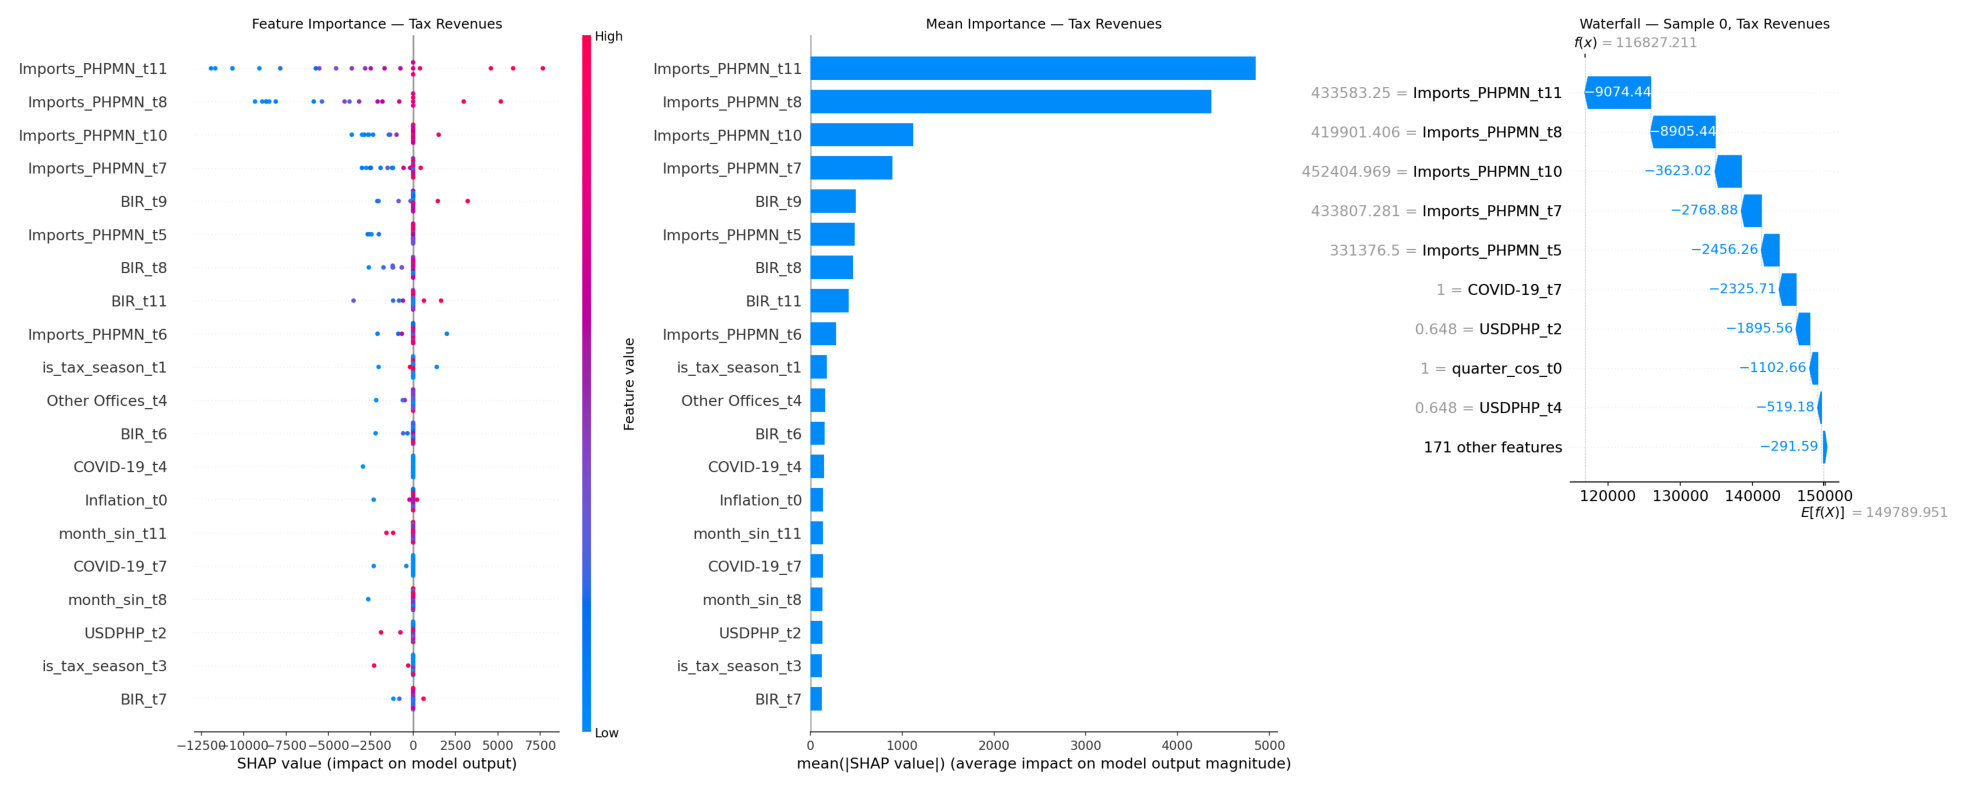

  Loaded 10 seed models


100%|██████████| 20/20 [01:18<00:00,  3.90s/it]


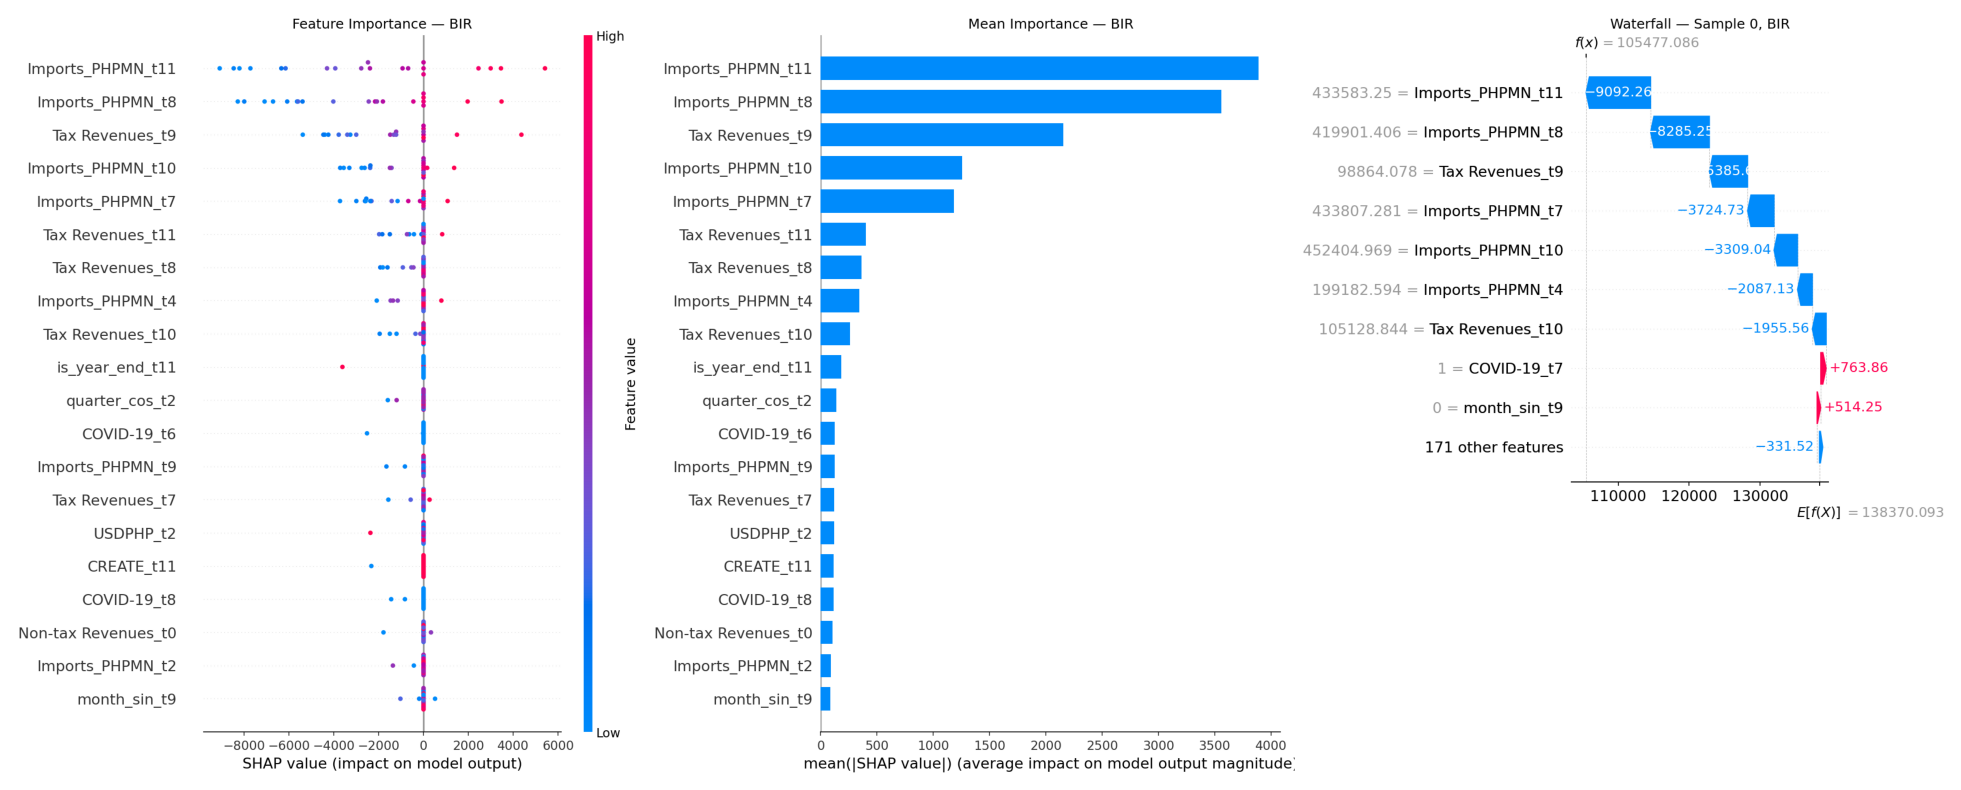

  Loaded 10 seed models


100%|██████████| 20/20 [00:06<00:00,  3.11it/s]


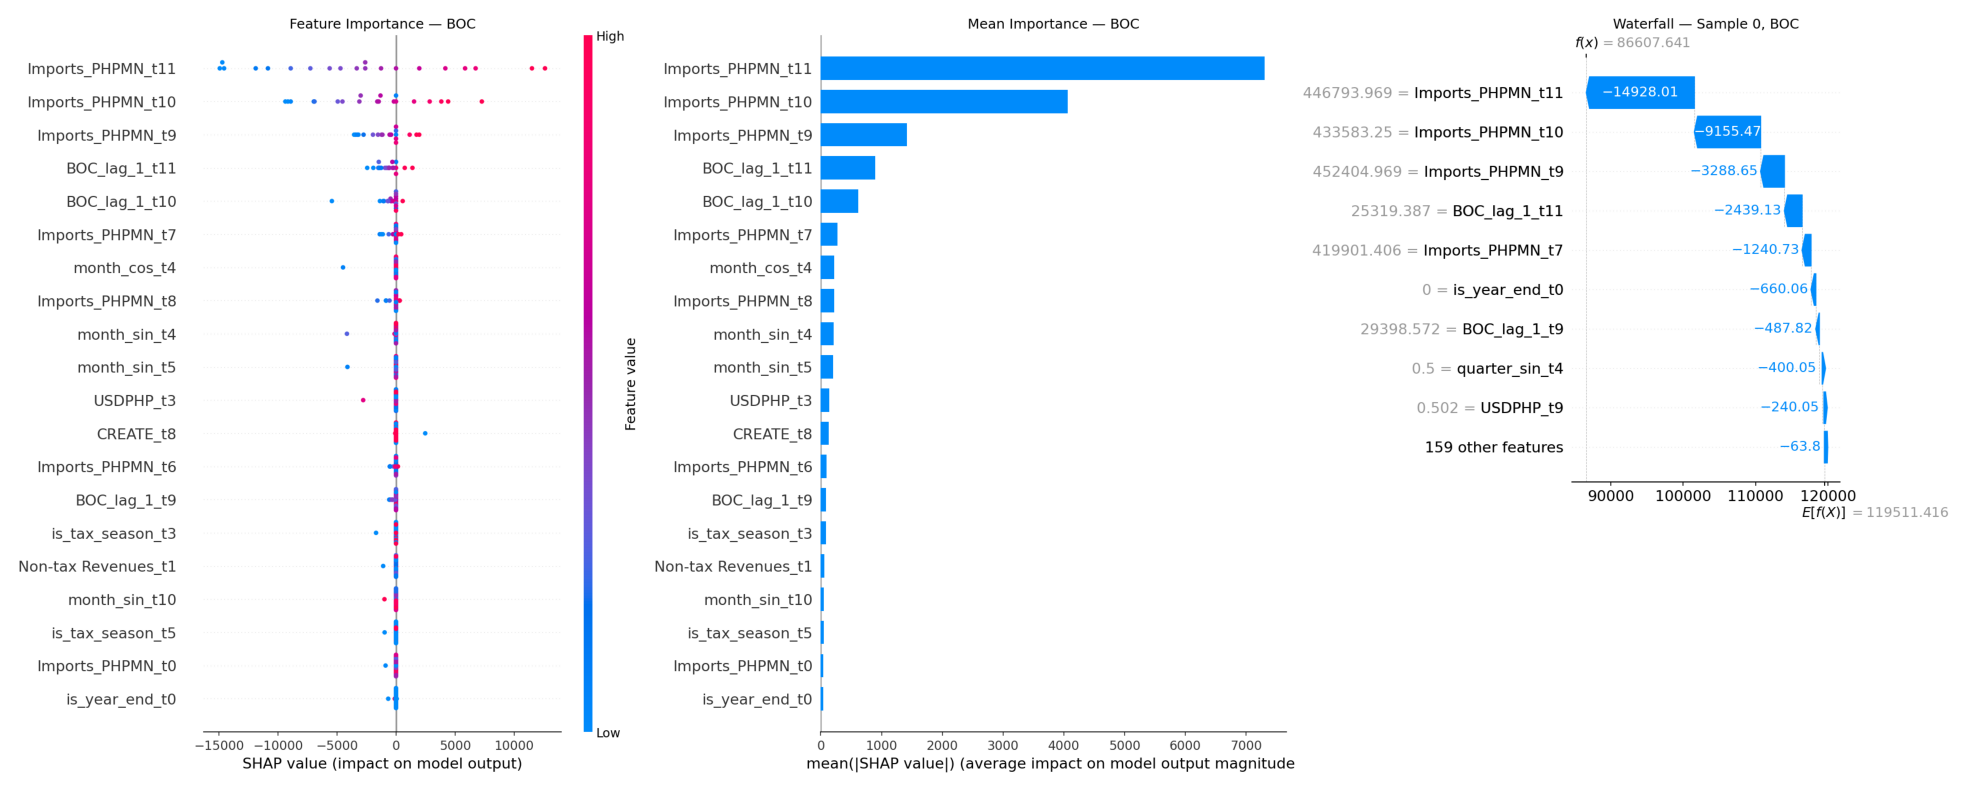

  Loaded 10 seed models


100%|██████████| 20/20 [00:20<00:00,  1.02s/it]


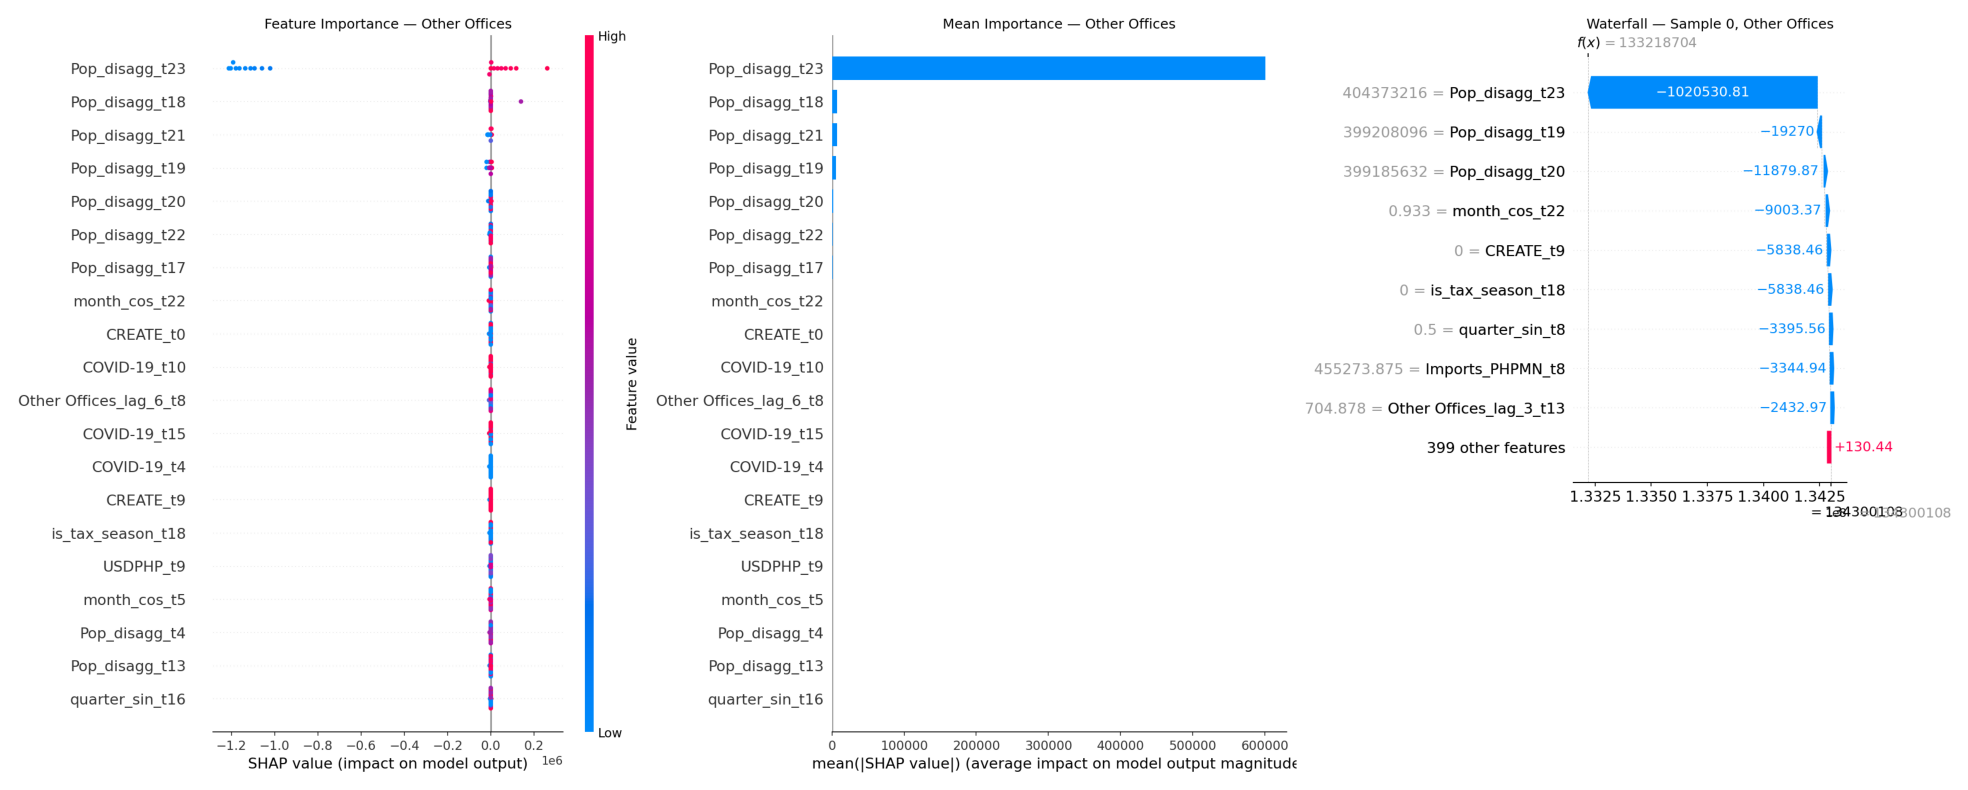

  Loaded 10 seed models


100%|██████████| 20/20 [02:17<00:00,  6.89s/it]


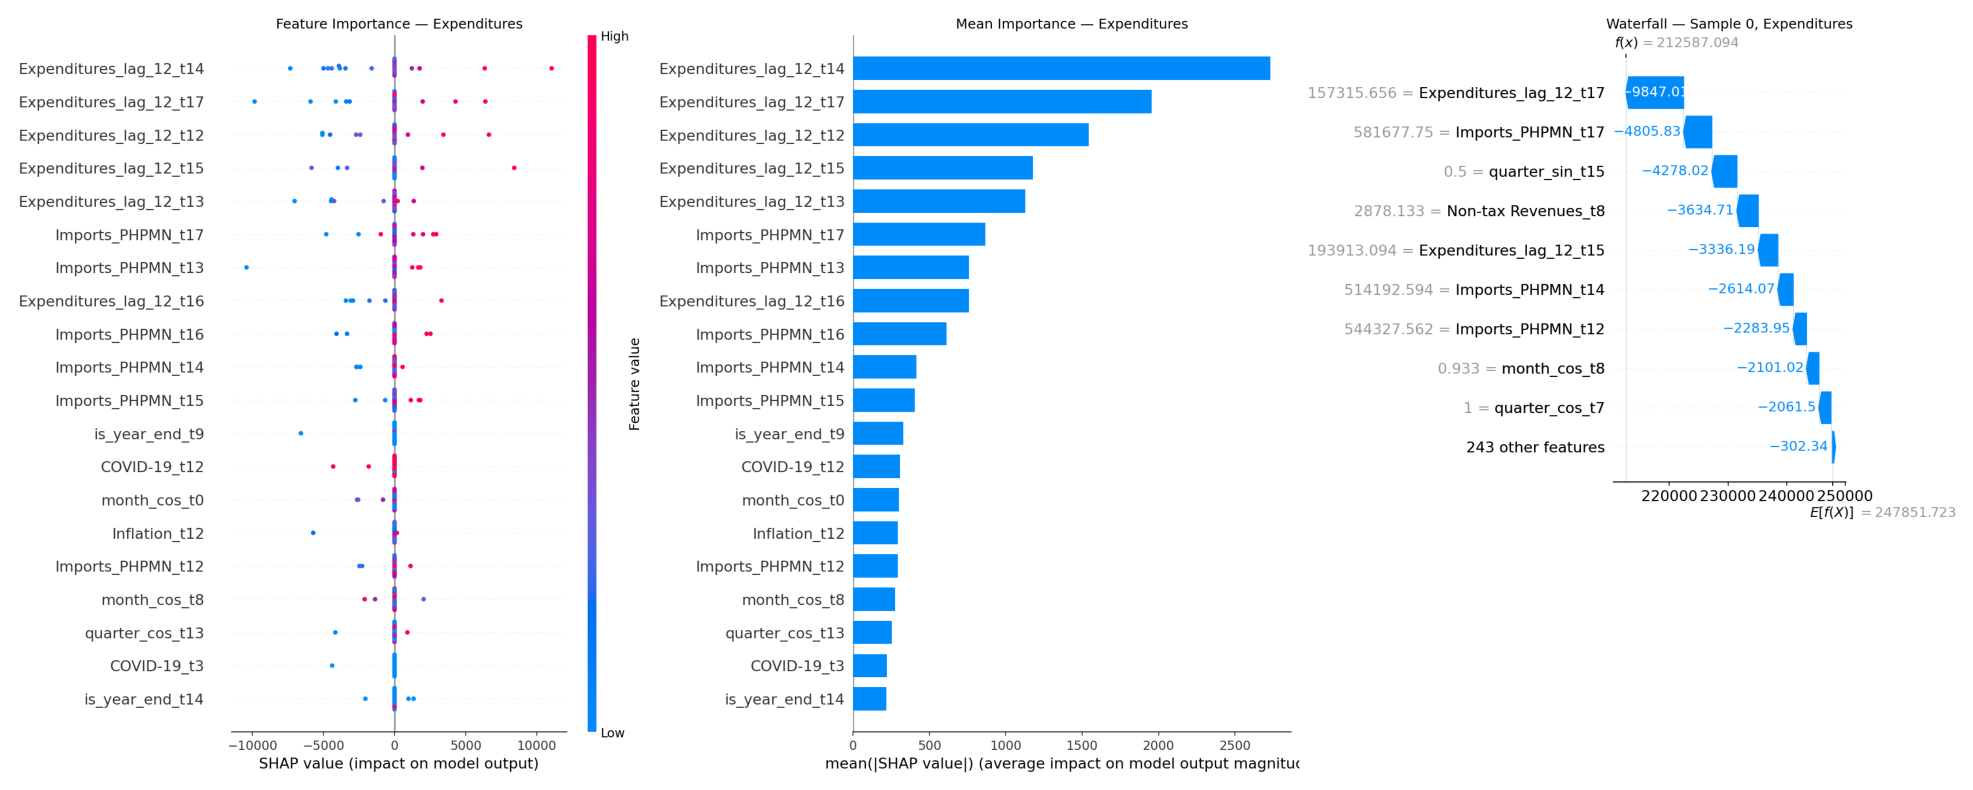

In [36]:
# ============================================================
# SHAP EXPLANATIONS 
# ============================================================

N_SEEDS = 10
START_DATES = [ "2000-01-01"]
EXPERIMENTS_TO_EXPLAIN = []
for start_date in START_DATES:
    for label in LABEL_COLS:
        label_slug = label.replace(' ', '_')
        tag = FEATURE_CONFIGS[label].get("tag", "")
        exp_name = f"{label_slug}_{start_date[:4]}_{tag}" if tag else f"{label_slug}_{start_date[:4]}"
        EXPERIMENTS_TO_EXPLAIN.append((exp_name, label))

for exp_name, label in EXPERIMENTS_TO_EXPLAIN:
    results_folder = f"results/{exp_name}"
    config_folder = f"configs/{exp_name}"
    
    with open(f"{config_folder}/best_config.json", "r") as f:
        best_config = json.load(f)
    
    args = train.Arguments(**best_config)
    
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    args.device = device
    
    dataset = train.load_dataset(args)
    
    # Load fitted scalers and transform test data
    with open(f"Transforms/{exp_name}/train_scaled.pkl", "rb") as f:
        data_scaler = pickle.load(f)
    with open(f"Transforms/{exp_name}/labels_scaled.pkl", "rb") as f:
        label_scaler = pickle.load(f)
    
    test_scaled = data_scaler.transform(dataset['test_data'])
    test_labels_scaled = label_scaler.transform(dataset['test_labels'])
    
    test_dataset = data.TimeSeriesDataset(test_scaled, test_labels_scaled, seq_len=args.seq_len)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Backward compatibility for older configs that still use hidden_size/num_layers.
    if hasattr(args, 'num_channels') and args.num_channels is not None:
        num_channels = list(args.num_channels)
    elif hasattr(args, 'hidden_size') and hasattr(args, 'num_layers'):
        num_channels = [args.hidden_size] * args.num_layers
    else:
        num_channels = [64, 64]
    
    # Load ensemble
    ensemble_models = []
    for seed in range(1, N_SEEDS + 1):
        train.set_seed(seed)
        m = TCNRegressor(
            input_size=dataset['input_size'],
            num_channels=num_channels,
            output_size=1,
            kernel_size=getattr(args, 'kernel_size', 2),
            dropout=getattr(args, 'dropout', 0.0),
        ).to(device)
        m.load_state_dict(torch.load(f"{results_folder}/model_seed_{seed}.pth", map_location=device))
        m.eval()
        ensemble_models.append(m)
    
    print(f"  Loaded {len(ensemble_models)} seed models")
    
    explainer, shap_values, test_data_shap, feature_names = utils.explain_model(
        ensemble_models, test_loader, args, num_samples=100
    )
    shap_values = shap_values.squeeze(-1)
    utils.plot_shap_combined(
        explainer, shap_values, test_data_shap, feature_names,
        output_name=label, save_dir=results_folder
    )
    #utils.plot_shap_summary(shap_values, test_data_shap, feature_names, output_name=label)
    #utils.plot_shap_bar(shap_values, test_data_shap, feature_names, output_name=label)
    #utils.plot_shap_waterfall(explainer, shap_values, test_data_shap, feature_names, sample_idx=0, output_name=label)